In [1]:
from pathlib import Path
import sys
ROOT=Path.cwd()
if ROOT.name=='Colab Notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'MATLAB_TRKG4_real_subjects/output/exploratory/arm_sigma_20260908/python_solver_deps'))
sys.path.insert(0,str(ROOT/'MATLAB_TRKG4_real_subjects/tools'))
import resistivity_refinement_report as report
import resistivity_refinement_interpretation as interpretation
r=report.load_report()

# 40.08. Достаточность перебора удельного сопротивления для оценки чувствительности электродных сборок

**Вычислительное исследование на фиксированной КТ-геометрии и конечноэлементной модели Nix при 50 кГц.** Работа относится к разработке методики и не имеет статуса независимой экспериментальной или клинической валидации.

## Аннотация

Исследование проверяет, достаточно ли пяти значений удельного сопротивления каждого из трёх целых компартментов для описания чувствительности 16 электродных сборок и их взаимного сравнения. Наряду со 125 узлами полного декартова перебора для каждой сборки рассчитаны 64 независимых промежуточных состояния. Основной результат, критерии решения и его практическое значение приведены перед подробным описанием метода.

In [2]:
interpretation.report_header(r)
report.status(r)

## 1. Основной результат

Полный перебор завершён для **16 электродных сборок и 3024 состояний**. Пятиуровневая сетка по удельному сопротивлению достаточно точно воспроизводит производную каждой сборки и показатель избирательности в 64 независимо рассчитанных промежуточных состояниях: ни одна из 3072 индивидуальных проверок не превысила установленный допуск.

Общий критерий достаточности **не выполнен**. Ошибка интерполяции разности модулей производных превысила допуск в **444 из 7680 проверок (5,78 %) для сердца** и в **432 из 7680 (5,62 %) для лёгких**. Для мягких тканей превышений не обнаружено. Таким образом, сетка 5 × 5 × 5 пригодна для оценки отдельной сборки, но пока недостаточна для окончательного ранжирования близких сборок по сердечной и лёгочной чувствительности.

### Рабочие рекомендации по целевому компартменту

| Целевой компартмент | Рекомендуемая сборка для следующего этапа | Основание |
|---|---|---|
| **Мягкие ткани** | **№ 15:** четыре диска диаметром 5 мм, d = 40 мм, l = 80 мм | Эта сборка имеет наибольшее минимальное B и одновременно входит в предпочтительное множество по Q. |
| **Сердечная область** | **№ 3 и № 7:** четыре диска диаметром 5 мм, d = 20 мм, l = 100 или 80 мм | Эти сборки имеют наибольшее минимальное B. Единственный лидер по Q не установлен: все варианты с d = 20 мм численно близки. |
| **Лёгкие, если важнее абсолютное влияние B** | **№ 3 и № 7:** четыре диска диаметром 5 мм, d = 20 мм, l = 100 или 80 мм | Получены наибольшие минимальные B, однако общий разброс между сборками составляет только 0,163 %. |
| **Лёгкие, если важнее избирательность Q** | **№ 4 и № 8:** манжеты шириной 15 мм, d = 20 мм, l = 100 или 80 мм | Эти сборки имеют наибольшее минимальное Q лёгких. Рост Q связан преимущественно с уменьшением мягкотканного влияния. |

**Практический выбор.** Для мягких тканей текущий расчёт даёт одну основную рекомендацию — сборку № 15. Для сердца следует сохранить обе дисковые сборки № 3 и № 7: расчёт не даёт основания выбирать между l = 80 и 100 мм. Для лёгких выбор зависит от задачи: № 3 и № 7 предпочтительны по B, а № 4 и № 8 — по Q.

### Влияние характеристик сборки

| Изменяемая характеристика | Наблюдение в модели | Практическое следствие |
|---|---|---|
| **Положение внутренних электродов: d = 40 → 20 мм** | Минимальные Q сердца и лёгких выросли примерно на 37,9 %. Значения B для сердца и лёгких почти не изменились, а мягкотканное B уменьшилось примерно на 31 %. | Меньшее d повышает избирательность к сердцу и лёгким главным образом за счёт ослабления мягкотканного влияния. |
| **Расстояние l = 100 → 80 мм** | Медианное изменение B близко к нулю; наибольшее отдельное изменение не превышает 0,262 %. | В диапазоне 80–100 мм уменьшение l не даёт подтверждённого преимущества. Значение можно выбирать по удобству установки до дополнительной проверки. |
| **Ширина манжеты: 5 → 15 мм** | Передаточный импеданс снизился на 4,46 %, мягкотканное B — на 4,75 %. Значения B для сердца и лёгких изменились менее чем на 0,002 %, а соответствующие значения Q выросли примерно на 4,26 %. | Большая манжета повышает относительную избирательность, но не увеличивает абсолютное влияние сердца или лёгких. |
| **Тип контакта** | Диски диаметром 5 мм выделяются по B, манжеты шириной 15 мм — по Q лёгких. | Тип контакта следует выбирать по целевому показателю; универсально лучшего типа в расчёте нет. |

Невыполнение общего критерия относится к точности сравнения очень близких значений B. Оно не свидетельствует о физической непригодности электродов. Перечисленные сборки являются рабочими кандидатами для следующего расчёта, а не клинически оптимизированными конфигурациями.

**Решение по зафиксированным критериям: требуется дальнейшее уточнение перебора.** Это результат численного эксперимента для выбранной модели и диапазонов.

,Условие,Результат
0,Полнота матрицы и численные проверки FEM,Выполнено
1,Интерполяция производных по сопротивлению,Выполнено
2,Интерполяция избирательности,Выполнено
3,Интерполяция парных разностей модулей производных,Не выполнено
4,Интерполяция парных разностей избирательности,Выполнено
5,Устойчивость знаков численно различимых пар,Выполнено
6,Устойчивость минимальных показателей,Выполнено
7,Устойчивость предпочтительных множеств,Выполнено


## 2. Постановка, параметры и критерии

### Назначение и статус исследования

Цель вычислительного эксперимента — установить, достаточно ли подробно исследована зависимость чувствительности электродных сборок от удельного сопротивления целых тканевых компартментов. Дополнительно проверяется устойчивость количественных различий между сборками и их предпочтения по заданному целевому компартменту. Критерии проверки определены до анализа новых результатов. Расчёт завершён; решение о достаточности основано на этих критериях.

Исследование продолжает отчёт [40.07](40.07_Чувствительность_сборок_по_удельному_сопротивлению.ipynb). В предыдущей серии проверка промежуточных состояний выявила недостаточную точность интерполяции производных по сопротивлению сердца и лёгких. Поэтому новый эксперимент увеличивает число комбинаций электрических параметров на прежней пространственной модели, построенной по КТ и рассчитанной методом конечных элементов (FEM). Полученные результаты характеризуют принятую КТ/FEM-постановку; экспериментальная валидация и пространственная сходимость рассматриваются отдельно.

### Фиксированные входы и допущения

Используются прежняя геометрия Nix, тканевые маски, контактные матрицы и 16 вариантов расположения и формы электродов. Модель содержит 752 827 узлов и 4 358 825 тетраэдров. Вокселизация оболочки с шагом 1 мм и заданное локальное сгущение на руках не означают равномерной объёмной FEM-сетки 1 мм: для туловища при построении задан размер элементов 12 мм.

Каждый из трёх параметров изменяется равномерно во всём соответствующем компартменте. Мягкотканный фон включает модельные продолжения рук. Сердце представлено целой эффективной областью крови и миокарда; отдельная маска крови и её измеренная доля отсутствуют. Геометрические границы фиксированы. В смешанном монтаже наружные токовые электроды являются поперечными плоскостями, а внутренние измерительные — поверхностными манжетами.

Сохраняются действительная скалярная электропроводность, частота 50 кГц, фиксированные свойства костей и контактов. Шум прибора, ошибки положения электродов и межсессионная физиологическая изменчивость в этот численный эксперимент не включаются. Указанные ниже допуски являются выбранными критериями вычислительной достаточности и не задают точность реальных измерений.

### Диапазоны и полный перебор

Границы взяты из ранее зафиксированного литературного профиля Gabriel/IT’IS. Их происхождение и ограничения переноса подробно раскрыты в отчёте 40.07. Это модельные интервалы между тканевыми и состояниевыми ориентирами при 50 кГц. Они не являются измеренными амплитудами изменений сопротивления во время пульса или дыхания.

| Компартмент | Нижняя граница ρ, Ом·м | Верхняя граница ρ, Ом·м | Число уровней |
|---|---:|---:|---:|
| Мягкотканный фон | 2,84230 | 23,10861 | 5 |
| Сердечная область | 1,42694 | 5,11678 | 5 |
| Лёгкие | 3,81728 | 9,74127 | 5 |
| Кости | 48,44513 | 48,44513 | Фиксировано |

По каждой изменяемой координате используются пять равноотстоящих значений **ρ**, включая границы. Выполняется полный декартов перебор 5 × 5 × 5 = 125 состояний на сборку. Каждый второй уровень образует вложенный перебор 3 × 3 × 3 = 27 состояний. Он позволяет сравнить итоговые показатели при увеличении плотности перебора, сохраняя одинаковые границы.

Для независимого контроля интерполяции дополнительно рассчитываются центры всех 4 × 4 × 4 = 64 ячеек. Значения в этих точках не используются при построении проверяемой интерполяции. Всего требуется 189 состояний на сборку и 3024 состояния для 16 сборок. Из них 128 угловых состояний совпадают с ранее выполненными прямыми расчётами; их повторное использование допускается после проверки контрольных сумм и параметров. Новых FEM-решений требуется 2896.

Вложенная сетка из 27 состояний отличается от исторического неравномерного перебора, использованного в отчёте 40.07. Совпадение ответов в общих узлах новой сетки само по себе не служит проверкой интерполяции: такую проверку обеспечивают дополнительные состояния.

### Определение оцениваемых величин

В каждом состоянии рассчитываются передаточный импеданс Z и знаковая производная S по сопротивлению целого компартмента:

$$S_t=\frac{\partial Z}{\partial\rho_t}=-\sigma_t^2\frac{\partial Z}{\partial\sigma_t},$$

где σ = 1/ρ — электропроводность, См/м; индекс t обозначает компартмент; Z выражается в омах, а S — в м⁻¹. Остальные параметры при вычислении частной производной фиксированы. Затем это вычисление повторяется при всех выбранных сочетаниях фоновых сопротивлений.

Для сопоставления целевых влияний используются Bₜ = |Sₜ|Δρₜ и Qₜ = Bₜ/ΣBₖ, где Δρₜ — ширина зафиксированного интервала сопротивления компартмента, то есть разность его верхней и нижней границ; суммирование выполняется по трём варьируемым компартментам. Величина B имеет размерность ома и характеризует локальную производную, приведённую к общему литературному масштабу. Она не подменяет конечное изменение импеданса на всём интервале. Величина Q безразмерна и показывает относительный вес соответствующего масштабированного влияния среди трёх варьируемых компартментов. Конечные изменения импеданса рассчитываются отдельно по решениям на границах диапазона.

Для каждой сборки и компартмента анализируются знак и диапазон S, а также диапазоны B и Q. Отдельно определяются минимальные B и Q по всем рассчитанным состояниям. Эти два показателя используются как самостоятельные критерии; их произвольная взвешенная сумма не вводится.

### Проверка производных и межсборочных различий

Интерполяция выполняется линейно по каждой из трёх координат ρ для знаковой S. Из интерполированных производных повторно вычисляются B и Q. В центрах ячеек результат сравнивается с производной, непосредственно полученной из конечноэлементного решения.

Допуск для S равен 5% её прямого значения по модулю плюс 0,5% максимального модуля на узлах данной сборки и компартмента. Допуск для Q составляет 0,005, то есть 0,5 процентного пункта. Добавочный масштаб в проверке S позволяет работать вблизи нуля; он не является оценкой приборного шума.

Различия сборок проверяются непосредственно для каждой из 120 пар. Для одного состояния и целевого компартмента рассматриваются разность модулей производных и разность Q. Погрешность интерполяции разности вычисляется как разность интерполированных показателей минус разность прямых показателей. Погрешности отдельных сборок не складываются как независимые: такой расчёт сохраняет возможную компенсацию связанных ошибок.

Для разности модулей производных допуск составляет 5% модуля прямой разности плюс 0,01% наибольшего прямого модуля S среди сборок в том же состоянии и для того же компартмента. Для разности Q используется 5% модуля прямой разности плюс 0,0001, то есть 0,01 процентного пункта. Если сама разность находится внутри принятой численной полосы, пара отмечается как неразличимая по этому критерию; различие знаков почти нулевых величин не превращается в доказанное изменение предпочтения. При этом ошибка интерполяции разности должна пройти свой допуск даже для неразличимой пары.

### Критерии достаточности параметрической сетки

Решение принимается совместно по следующим условиям:

1. Все предусмотренные решения завершены с проверкой невязки, взаимности и происхождения данных.
2. Производные и Q проходят контроль в дополнительных состояниях.
3. Прямые межсборочные разности проходят собственный контроль интерполяции; сохраняется возможность неразличимых пар.
4. При переходе от вложенного перебора 3³ к 5³ минимальные B изменяются не более чем на 1% от большего из двух сравниваемых минимумов, а минимальные Q — не более чем на 0,0005, или 0,05 процентного пункта.
5. Предпочтительные множества сборок устойчивы как при переходе от 3³ к 5³, так и после добавления контрольных состояний. В множество включаются сборки, отстающие от максимального минимального B не более чем на 0,01% от этого максимума; для максимального минимального Q используется полоса 0,0001. Проверяется также изменение самих минимальных показателей после добавления контрольных состояний.

Прохождение этих условий означает эмпирическую достаточность для предусмотренных проверок данной модели и выбранного профиля. Оно не доказывает отсутствие особенностей во всех точках непрерывного диапазона. Если хотя бы одно условие не выполнено, отчёт должен указать причину, проблемные компартменты и области параметров. Следующий уровень потребует дальнейшего увеличения плотности перебора. Матрица 9³ не считается выполненной и не запускается автоматически в рамках этой первой попытки.

Предпочтение всегда относится к определённому компартменту и показателю. Различные сборки могут быть предпочтительны для разных целей. Совпадение результатов по одному критерию не делает сборки одинаковыми по всем характеристикам, а численно малое преимущество не считается установленным практическим преимуществом.

### Воспроизводимость вычислений

Конечноэлементные решения выполняются функцией `run_pipeline` с профилем `electrode_sensitivity`. Вместе с результатами сохраняются параметры расчёта, версия исходного кода и контрольные суммы. В анализ включаются только полностью завершённые наборы решений.

Воспроизводимый отчёт включает параметры сетки, значения чувствительности, ошибки в контрольных состояниях, парные сравнения и проверку устойчивости минимумов. Технический журнал расчёта хранится отдельно.


## 3. Структура параметрического перебора и геометрия сборок

Рисунок 1 необходим для проверки того, что контрольные состояния расположены между основными узлами и не используются при построении проверяемой интерполяции.

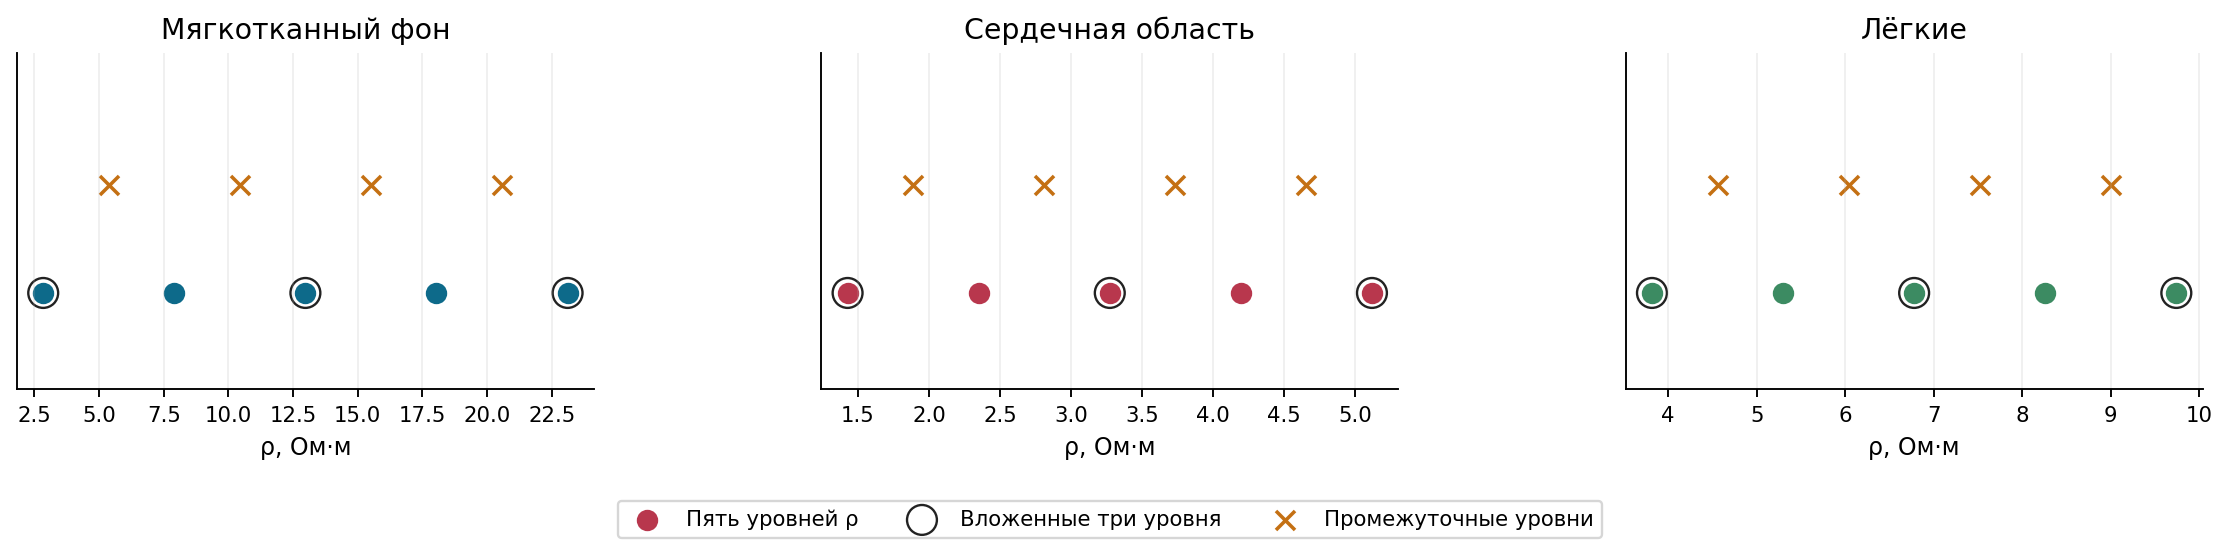

**Рисунок 1.** Уровни сопротивления по трём координатам. Все сочетания пяти основных уровней образуют 125 узлов. Все сочетания четырёх промежуточных уровней образуют 64 центра ячеек для независимого контроля интерполяции.

**Анализ рисунка 1.** На рисунке показано разбиение литературных диапазонов удельного сопротивления на расчётные и контрольные значения. Для мягких тканей шаг основной сетки равен 5,067 Ом·м, для сердечной области — 0,922 Ом·м, для лёгких — 1,481 Ом·м.

**Основной результат.** Пять уровней каждого параметра образуют 125 основных состояний. Ещё 64 состояния расположены между узлами основной сетки и рассчитаны независимо. Поэтому они проверяют точность интерполяции внутри диапазона, а не повторяют значения, использованные для её построения.

**Научный смысл.** Полный совместный перебор позволяет оценивать производную по одному компартменту при разных сопротивлениях двух остальных компартментов. Сам рисунок описывает план вычислительного эксперимента; сравнения чувствительности сборок приведены на последующих рисунках.

In [3]:
report.design(r)
interpretation.design_analysis(r)

### Геометрия сравниваемых сборок

Нумерация из таблицы используется во всех последующих рисунках и сводках. Рисунок 2 связывает каждый номер с типом контакта и двумя расстояниями: d отсчитывается от границы туловища и модельной руки до внутреннего измерительного контакта, l — от внутреннего контакта до наружного токового электрода.

№,Электроды,"Ориентир — измерительная манжета/диск, мм","Измерительный — токовый электрод, мм"
1,Манжеты 5 мм,20,100
2,Токовые плоскости и измерительные манжеты,20,100
3,Диски 5 мм,20,100
4,Манжеты 15 мм,20,100
5,Манжеты 5 мм,20,80
6,Токовые плоскости и измерительные манжеты,20,80
7,Диски 5 мм,20,80
8,Манжеты 15 мм,20,80
9,Манжеты 5 мм,40,100
10,Токовые плоскости и измерительные манжеты,40,100


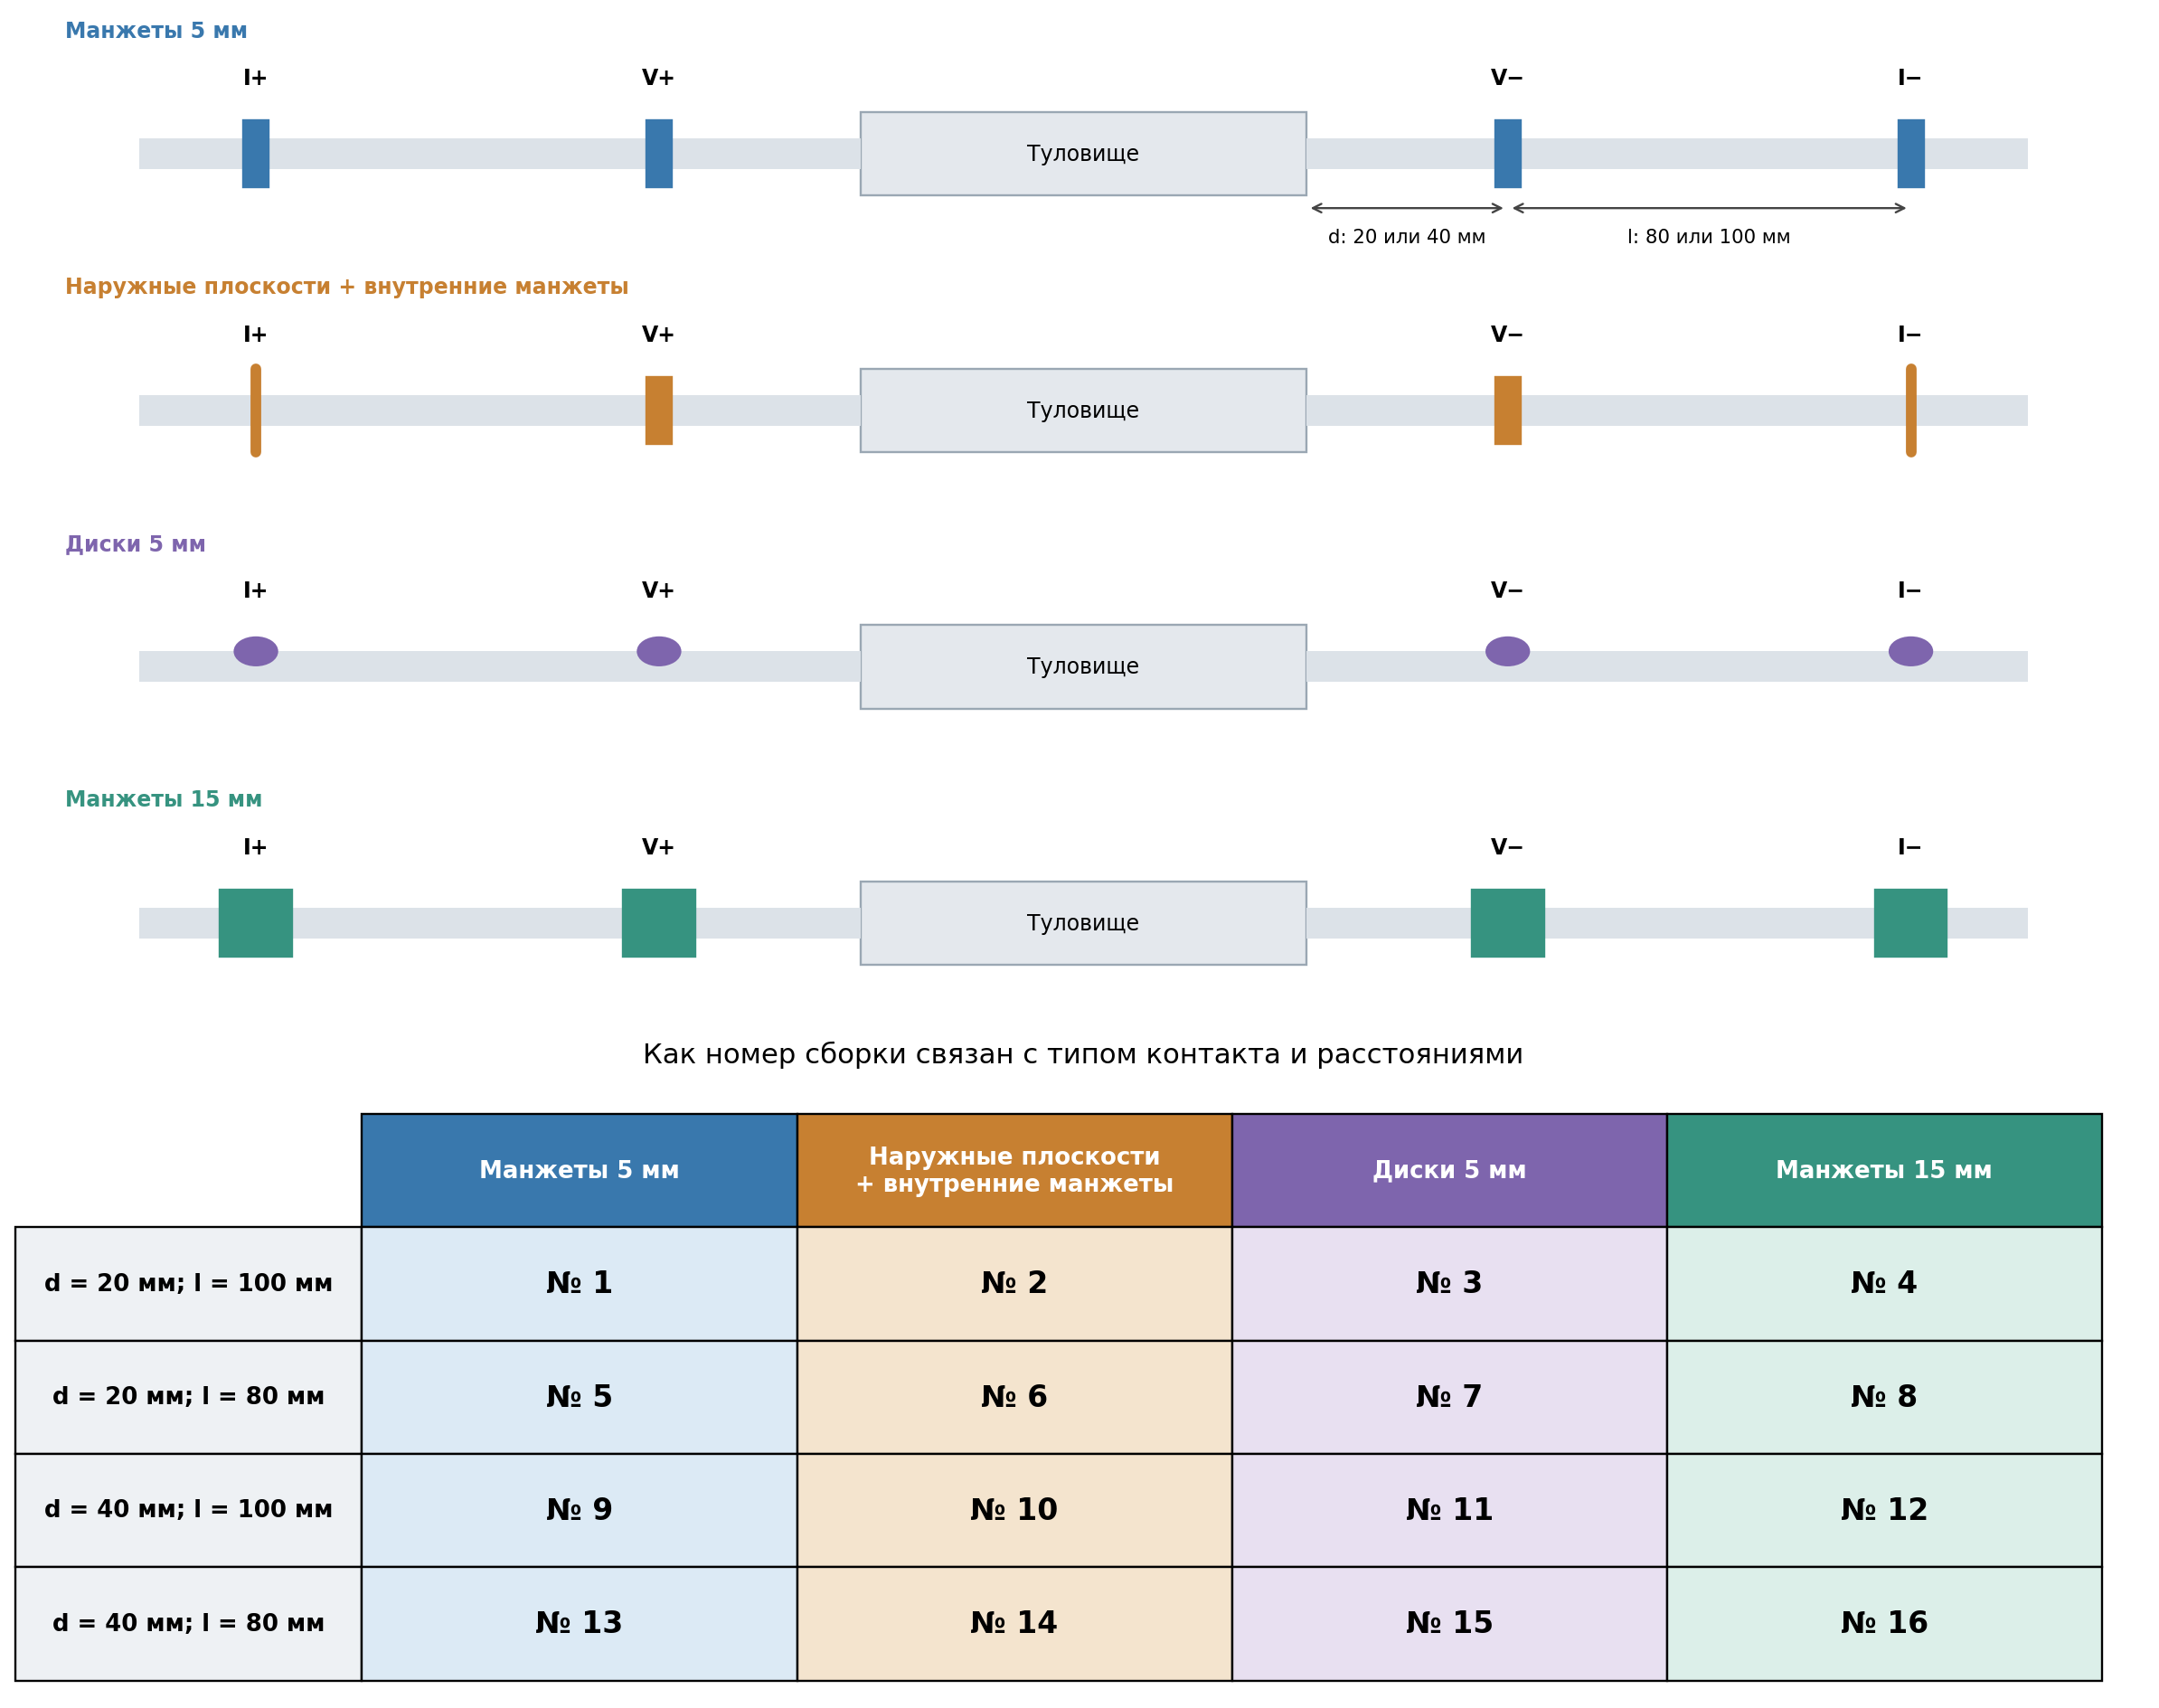

**Рисунок 2.** Схема четырёх типов контактов и карта номеров 16 сборок. I — наружные токовые электроды, V — внутренние измерительные; d — расстояние от границы туловища до измерительного электрода, l — расстояние от измерительного до наружного токового электрода. Схема симметрична относительно туловища; анатомический масштаб условный.

**Анализ рисунка 2 и таблицы сборок.** На рисунке 16 сборок расположены по трём изменяемым признакам: положению внутреннего измерительного контакта d, расстоянию l до наружного токового электрода и типу контакта.

Номера 1–4 соответствуют d = 20 мм и l = 100 мм, номера 5–8 — d = 20 мм и l = 80 мм. Номера 9–12 и 13–16 повторяют эти два значения l при d = 40 мм. В каждой группе типы контактов идут в одном порядке: манжета 5 мм, смешанная сборка с наружными плоскостными электродами, четыре диска диаметром 5 мм и манжета 15 мм.

Например, сборка № 3 состоит из четырёх дисков диаметром 5 мм при d = 20 мм и l = 100 мм. Сборка № 7 отличается только значением l = 80 мм. В сборке № 15 те же диски расположены при d = 40 мм и l = 80 мм.

Такое расположение позволяет сравнивать сборки, отличающиеся одним геометрическим признаком. Все расчёты выполнены на одной анатомической модели, поэтому различия характеризуют данную модель и не являются оценкой межиндивидуальной изменчивости.

In [4]:
report.assembly_table(r)
report.assembly_map(r,2)
interpretation.assembly_analysis(r)

### Цветовые матрицы чувствительности и правила их трактовки

Расположение ячеек на рисунке 3 совпадает с картой сборок на рисунке 2. Верхний ряд показывает минимальное абсолютное влияние B для выбранного компартмента, нижний — минимальную избирательность Q. Числа и цвет позволяют сравнить сборки, а текст после рисунка объясняет результат и его ограничения.

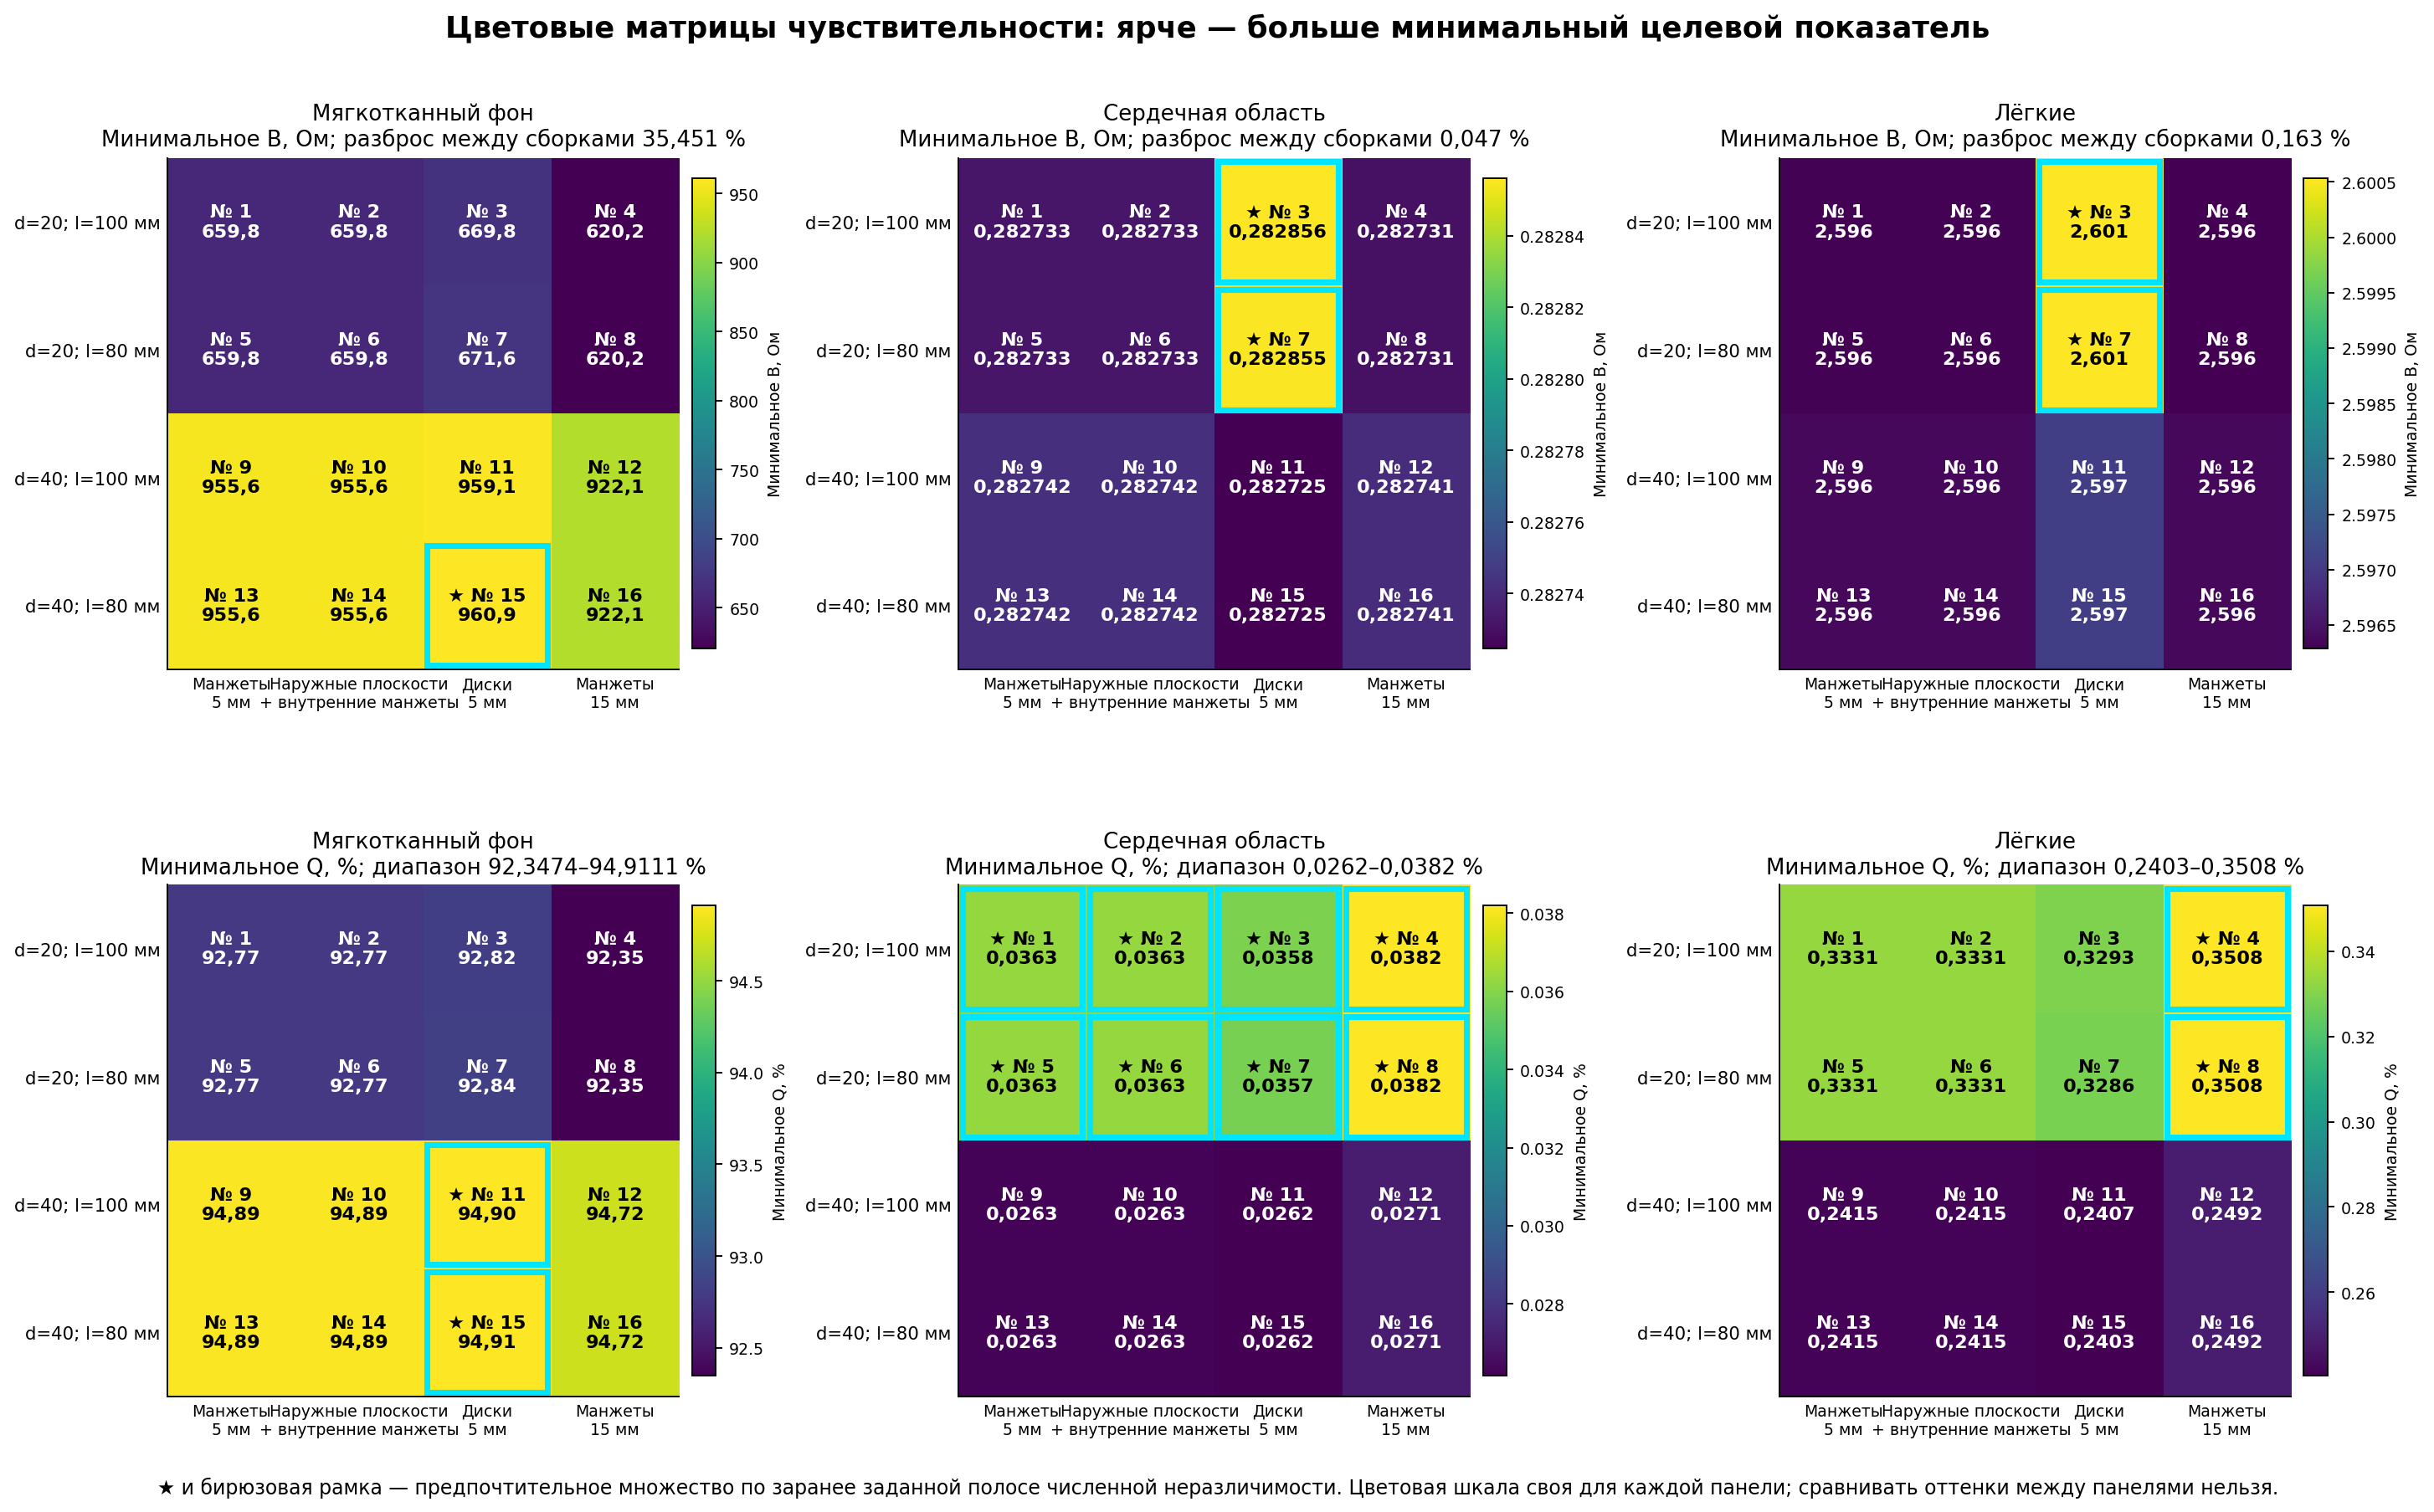

**Рисунок 3.** Минимальные значения локально масштабированной чувствительности B и избирательности Q для 16 сборок. Расположение ячеек повторяет карту рисунка 2. Яркий цвет соответствует большему минимальному значению показателя; звезда и бирюзовая рамка отмечают предпочтительное множество. Каждая панель имеет собственную числовую цветовую шкалу, поэтому оттенки сопоставимы только внутри одной панели.

**Анализ рисунка 3.** В каждом столбце рассматривается один целевой компартмент: мягкие ткани, сердечная область или лёгкие. Верхний ряд показывает минимальное по исследованной области значение абсолютного влияния B, нижний — минимальную избирательность Q. Строки и столбцы внутри каждой панели задают геометрию сборки.

Цвет отражает только порядок значений внутри отдельной панели. Цветовые шкалы между панелями различаются, поэтому величину эффекта следует оценивать по числам в ячейках. Звезда и бирюзовая рамка отмечают сборки, попавшие в заранее заданную полосу численной неразличимости с максимумом.

Задача,Что смотреть,Допустимая трактовка,Ограничение
Сравнить величину отклика на изменение выбранного компартмента,"Минимальное B, верхний ряд",Большее B соответствует большему ненормированному отклику во всех проверенных состояниях.,Значение B не является амплитудой пульса или дыхания и не равно конечному изменению Z на всём диапазоне.
Сравнить избирательность к выбранному компартменту,"Минимальное Q, нижний ряд","Большее Q означает, что целевой отклик занимает большую долю суммы трёх модельных откликов.",Q зависит от принятых диапазонов ρ и не является долей реальных физиологических источников.
Определить кандидатов,"Звёзды, рамки и числа в ячейках","Отмечены сборки, которые численно не отличаются от максимума по заданному допуску.","Несколько отмеченных ячеек означают, что единственный лидер не установлен."
Оценить надёжность различий,Числа в ячейках и рисунки 7–8,Окончательное ранжирование допустимо только после проверки ошибки разности между сборками.,Яркий цвет сам по себе не доказывает существенного преимущества.


#### Абсолютное влияние B

- **Мягкие ткани.** Наибольшее из минимальных значений B равно **960,889 Ом**. Оно получено для четырёх дисков диаметром 5 мм при d = 40 мм и l = 80 мм (№ 15). Диапазон между сборками составляет 620,244–960,889 Ом, а относительный разброс — 35,45 %. В данной модели геометрия электродов заметно влияет на мягкотканный отклик.
- **Сердечная область.** Кандидатами являются дисковые сборки при d = 20 мм и l = 100 или 80 мм: № 3, **0,282856 Ом**, и № 7, **0,282855 Ом**. Полный диапазон составляет 0,282725–0,282856 Ом, то есть разброс равен лишь 0,047 %. Численное преимущество этих сборок мало.
- **Лёгкие.** Выделены те же дисковые сборки № 3 и № 7: **2,600520** и **2,600532 Ом** соответственно. Диапазон всех значений равен 2,59628–2,60053 Ом, а разброс — 0,163 %. Различия между сборками также малы.

#### Избирательность Q

- **Мягкие ткани.** Наибольшие минимальные Q получены для дисков диаметром 5 мм при d = 40 мм и l = 100 или 80 мм: № 11, **94,9021 %**, и № 15, **94,9111 %**. Высокие значения связаны с большой объединённой мягкотканной областью и с шириной принятого диапазона ρ.
- **Сердечная область.** Единственный лидер не определён. В предпочтительное множество входят все сборки № 1–8, то есть варианты с d = 20 мм. Минимальное Q составляет 0,0262–0,0382 %. В рамках принятого масштабирования сердечный отклик мал по сравнению с суммарным влиянием мягких тканей и лёгких.
- **Лёгкие.** Наибольшее минимальное Q получено для манжет шириной 15 мм при d = 20 мм и l = 100 или 80 мм: № 4, **0,3508 %**, и № 8, **0,3508 %**.

#### Вывод по рисунку 3

Единой лучшей сборки по всем критериям не получено. Диски диаметром 5 мм имеют наибольшие значения B для выделенных целей, а манжеты шириной 15 мм имеют наибольшую лёгочную избирательность Q. Для сердца и лёгких различия B составляют доли процента. Поэтому рисунок выделяет кандидатов для уточняющего расчёта, но не задаёт окончательный рейтинг электродных сборок.

#### Абсолютная и относительная чувствительность

Для малого равномерного изменения удельного сопротивления одного компартмента изменение передаточного импеданса приближённо равно

$$
Z(\rho_t+\delta\rho_t)-Z(\rho_t)\approx
S_t(\boldsymbol{\rho})\,\delta\rho_t,
\qquad
S_t(\boldsymbol{\rho})=\frac{\partial Z}{\partial\rho_t}.
$$

Производная $S_t$ показывает, насколько быстро изменяется передаточный импеданс Z при изменении ρ выбранного компартмента. Значения ρ двух остальных компартментов при этом фиксированы. Поскольку они влияют на распределение тока, производная повторно вычисляется во всех предусмотренных фоновых состояниях.

Величина,Определение,Единицы,Что измеряет,Роль в сравнении
Знаковая дифференциальная чувствительность,$S_t=\partial Z/\partial\rho_t$,м⁻¹,Локальный наклон зависимости передаточного импеданса от ρ целого компартмента при фиксированных ρ остальных компартментов.,Описывает малое изменение около конкретного состояния; знак сохраняет направление отклика.
Локально масштабированное абсолютное влияние,$B_t=|S_t|\Delta\rho_t$,Ом,"Модуль локальной производной, умноженный на одинаковую для всех сборок ширину литературного диапазона ρ данного компартмента.",Позволяет сопоставлять компартменты с разными единицами масштаба изменения ρ; не является прямым конечным изменением Z на всём диапазоне.
Минимальное абсолютное влияние,$B_t^{min}=\min_{\rho\in\Omega} B_t(\rho)$,Ом,Наименьшее найденное B среди 125 узлов и 64 контрольных состояний.,"Характеризует наименее благоприятное из рассчитанных состояний, а не среднее ожидаемое состояние."
"Относительная чувствительность, или избирательность",$Q_t=B_t/(B_{soft}+B_{heart}+B_{lung})$,Безразмерная; в отчёте %,Доля целевого B в сумме трёх локально масштабированных влияний в одном и том же состоянии.,Показывает относительное преобладание цели над конкурирующими компартментами при принятом масштабировании.
Минимальная избирательность,$Q_t^{min}=\min_{\rho\in\Omega}Q_t(\rho)$,Безразмерная; в отчёте %,Наименьшее найденное Q по полной совокупности рассчитанных состояний.,Используется как консервативный критерий выбора сборки.


Величина $B_t=|S_t|\Delta\rho_t$ в отчёте называется **абсолютным влиянием**. Она имеет размерность сопротивления и не нормируется на другие компартменты. Слово «абсолютное» здесь не означает истинное значение без погрешности. B является локальной оценкой, построенной по производной и ширине литературного диапазона $\Delta\rho_t$. Значение B совпало бы с конечным $|\Delta Z_t|$ только при постоянной производной на всём интервале.

Ширина литературного диапазона одинакова для всех сравниваемых сборок одного компартмента. Поэтому внутри одного компартмента большее B означает больший модуль производной. Сравнение B разных компартментов зависит также от ширины выбранных диапазонов ρ. Эти диапазоны не задают амплитуды пульса или дыхания.

Величина

$$
Q_t=\frac{B_t}{B_{soft}+B_{heart}+B_{lung}}
$$

называется **относительной чувствительностью**, или избирательностью. Она показывает долю целевого B в сумме трёх модельных влияний. Для каждого состояния сумма трёх Q равна единице.

Q может увеличиться по двум причинам: выросло целевое B либо уменьшилось B другого компартмента. Поэтому Q всегда следует рассматривать вместе с тремя значениями B. В данной работе Q характеризует только структуру чувствительности математической модели. Этот показатель не является измеренной долей физиологических источников и не характеризует клиническую специфичность метода.

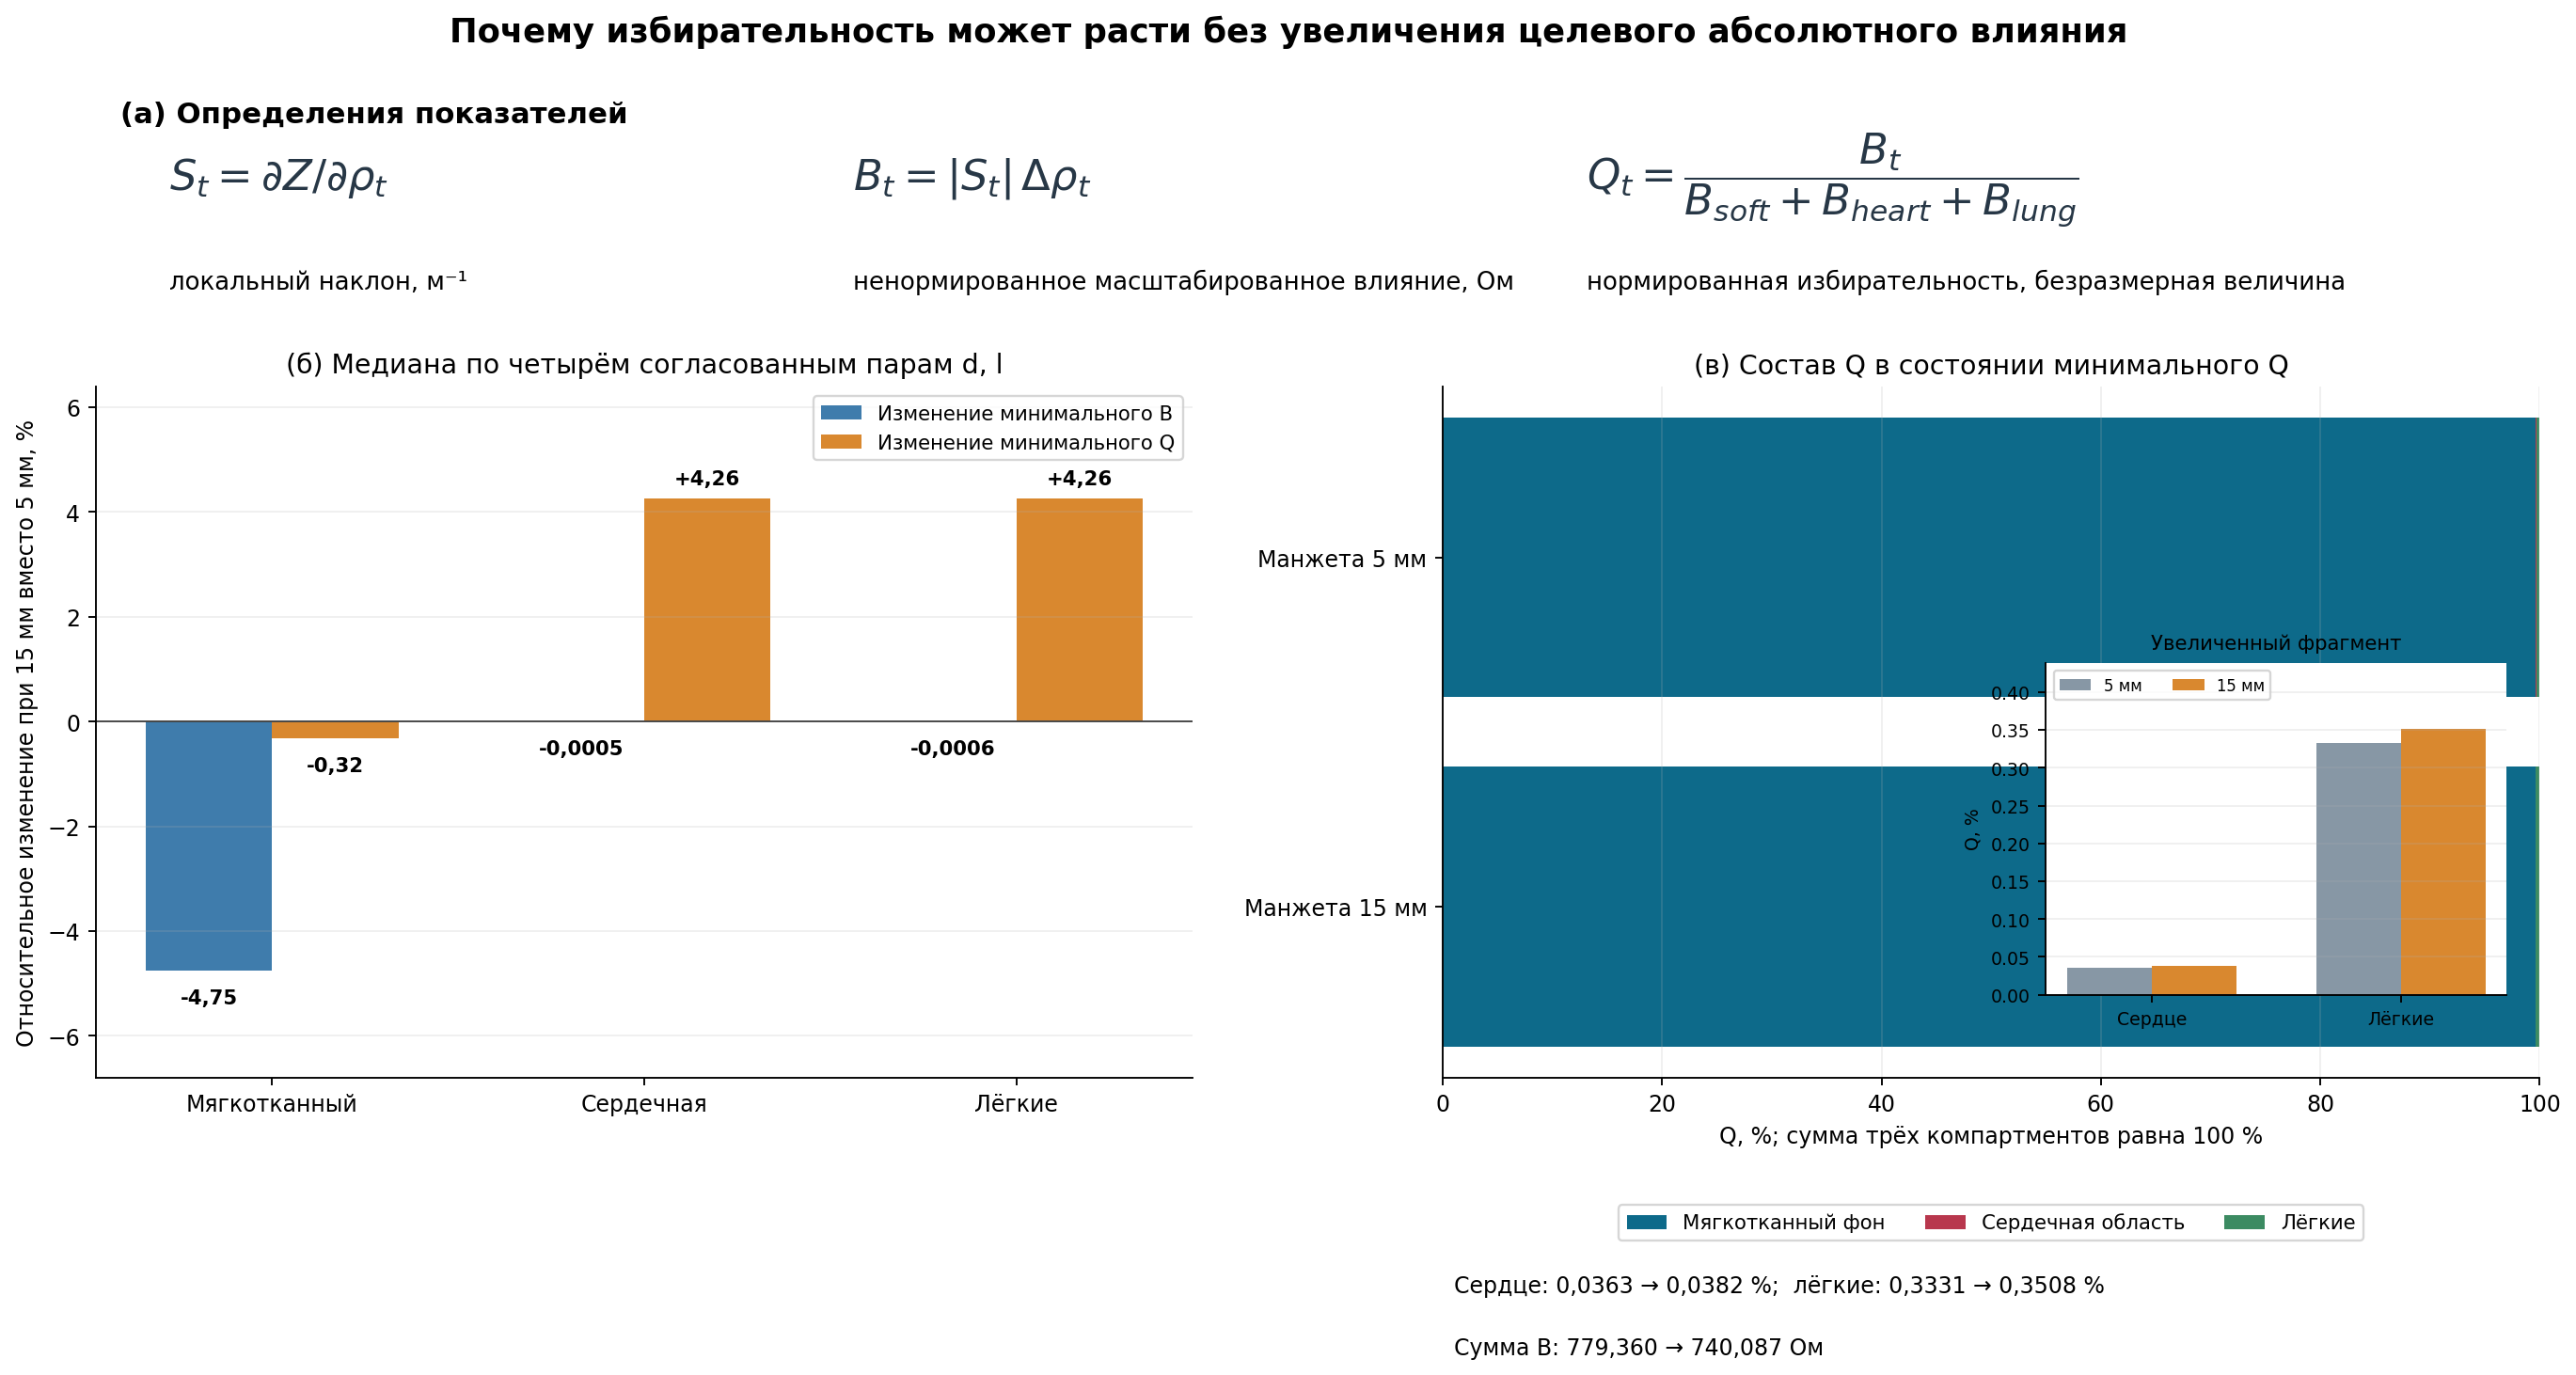

**Рисунок 4.** Связь производной S, локально масштабированного абсолютного влияния B и относительной избирательности Q. Панель б показывает медианное изменение минимальных B и Q при замене манжеты 5 мм на манжету 15 мм в четырёх согласованных сочетаниях d и l. Панель в показывает состав Q в узле, где для согласованной пары с d = 20 мм и l = 100 мм достигаются минимальные сердечное и лёгочное Q; итоговый критерий по каждой сборке определяется по всей параметрической области.

**Анализ рисунка 4.** Панель а показывает связь между производной S, абсолютным влиянием B и относительной чувствительностью Q. Панель б содержит медианные изменения минимальных B и Q при увеличении ширины манжеты с 5 до 15 мм. Панель в показывает тот же эффект на одном непосредственно рассчитанном состоянии.

**Основной результат.** Минимальные значения B для сердца и лёгких изменились менее чем на 0,002 %. Следовательно, увеличение ширины манжеты практически не усилило собственный отклик этих компартментов. Одновременно мягкотканное B уменьшилось, поэтому доля сердца и лёгких в суммарной чувствительности стала больше.

#### Механизм увеличения Q

Для двух вариантов электродов отношение относительных чувствительностей равно

$$
\frac{Q'_t}{Q_t}
=
\frac{B'_t}{B_t}
\frac{B_{soft}+B_{heart}+B_{lung}}
     {B'_{soft}+B'_{heart}+B'_{lung}}.
$$

Если целевое B почти не изменилось, первый множитель близок к единице. Если при этом уменьшилось доминирующее мягкотканное B, новая сумма в знаменателе становится меньше. В результате Q целевого компартмента увеличивается. Рост Q в данном случае отражает уменьшение конкурирующего мягкотканного влияния, а не усиление сердечного или лёгочного отклика.

Компартмент,"Изменение минимального B, %; медиана [диапазон]","Изменение минимального Q, %; медиана [диапазон]","Изменение минимального Q, п.п.; медиана [диапазон]"
Мягкотканный фон,"-4,75380 [-5,99703; -3,51058]","-0,322 [-0,458; -0,185]","-0,300304 [-0,424731; -0,175880]"
Сердечная область,"-0,00053 [-0,00074; -0,00032]","4,255 [3,205; 5,306]","0,001384 [0,000843; 0,001925]"
Лёгкие,"-0,00062 [-0,00101; -0,00023]","4,255 [3,205; 5,306]","0,012707 [0,007740; 0,017675]"


Таблица основана на четырёх попарных сравнениях. В каждой паре изменялась только ширина манжеты; d и l оставались одинаковыми.

Для сердца изменение минимального B составило от -0,00074 до -0,00032 %, для лёгких — от -0,00101 до -0,00023 %. Все изменения по модулю меньше 0,002 %. Минимальные значения Q сердца и лёгких при этом увеличились на 3,205–5,306 % относительно исходного уровня. Медианное увеличение равно 4,255 %.

Значение **4,255 % обозначает относительное изменение Q**. Это не прибавка на 4,255 процентного пункта. В абсолютной шкале прирост составляет 0,000843–0,001925 процентного пункта для сердца и 0,007740–0,017675 процентного пункта для лёгких.

...

Компартмент,"B, манжета 5 мм, Ом","B, манжета 15 мм, Ом","Изменение B, %","Q, манжета 5 мм, %","Q, манжета 15 мм, %"
Мягкотканный фон,"776,481272","737,207628","-5,05790","99,630589","99,610989"
Сердечная область,"0,282733","0,282731","-0,00074","0,036278","0,038202"
Лёгкие,"2,596311","2,596285","-0,00101","0,333134","0,350808"


Сумма трёх B уменьшается с 779,360 до 740,087 Ом, то есть на 5,039 %. Основной вклад в это уменьшение вносит мягкотканное B: 776,481 → 737,208 Ом. Изменение B равно -0,00074 % для сердца и -0,00101 % для лёгких.

При почти неизменном целевом B значение Q сердца возрастает с 0,0363 до 0,0382 %, а значение Q лёгких — с 0,3331 до 0,3508 %. Для этой конкретной пары относительное увеличение каждого Q равно 5,31 %. Медиана по четырём согласованным парам составляет 4,255 %.

Передаточный импеданс Z и чувствительность S описывают разные свойства модели. Z задаёт уровень передаточного импеданса, а S — скорость его изменения при изменении выбранного ρ. Поэтому уменьшение Z не означает автоматического увеличения чувствительности.

#### Выводы для проектирования следующих сборок

В таблице приведены попарные сравнения, в которых изменялся один геометрический параметр. Рассмотрены только d = 20 и 40 мм, l = 80 и 100 мм, а также манжеты 5 и 15 мм. Эти результаты относятся к одной анатомической модели и не являются популяционной оценкой.

Проверенная гипотеза,Наблюдение в модели,Практическая трактовка
Сместить внутренние электроды к плечам: d = 40 → 20 мм,"Медианное изменение минимального B: мягкие ткани -30,95 %, сердце -0,003 %, лёгкие -0,002 %. Значения минимального Q сердца и лёгких увеличились примерно на 37,9 % относительно исходного.",Значение d = 20 мм следует сохранить среди кандидатов для повышения избирательности к центральным компартментам. Рост их абсолютного влияния B не установлен.
Сблизить токовый и измерительный электроды: l = 100 → 80 мм,"Медианные изменения минимального B по трём компартментам лежат от -0,0000 до 0,0003 %. Наибольшее изменение для отдельного типа контакта не превышает 0,262 %.",В исследованном диапазоне 80–100 мм уменьшение l не дало устойчивого выигрыша по B или Q.
Увеличить ширину манжеты: 5 → 15 мм,"Медиана передаточного импеданса уменьшилась на 4,46 %. Минимальное мягкотканное B уменьшилось на 4,75 %. Минимальные B сердца и лёгких изменились менее чем на 0,002 %, а их минимальные Q выросли на 4,26 %.",Большая манжета повысила относительную избирательность за счёт уменьшения мягкотканного влияния. Увеличение целевого B не получено.


**Положение внутренних электродов.** Переход от d = 40 к 20 мм повысил минимальные значения Q сердца и лёгких примерно на 38 %, но уменьшил мягкотканное B примерно на 31 %. Значения B для сердца и лёгких почти не изменились. Поэтому d = 20 мм является кандидатом для повышения избирательности к центральным компартментам. Увеличение B сердца или лёгких при этом не установлено.

**Расстояние l.** Переход от 100 к 80 мм почти не изменил B и Q. Максимальный отдельный эффект по B равен 0,262 %. В пределах 80–100 мм правило «меньше расстояние — выше чувствительность» не подтверждено. Значения вне этого диапазона не исследовались.

**Ширина манжеты.** Манжета шириной 15 мм уменьшила медианный передаточный импеданс на 4,46 % и мягкотканное B на 4,75 %. Значения B для сердца и лёгких остались практически неизменными, но соответствующие значения Q увеличились примерно на 4,26 %. Следовательно, увеличение площади контакта может повысить избирательность без повышения абсолютной чувствительности к цели.

Рассчитанный Z является передаточным импедансом четырёхэлектродной модели. Он не равен электродно-кожному контактному импедансу. Контактное сопротивление во всех вариантах было фиксировано; подготовка кожи, качество фиксации и реальный разброс контакта не моделировались.

Для следующих пользовательских сборок следует заранее выбрать целевой компартмент и совместно оценивать B и Q. Для сердца и лёгких целесообразно сохранить варианты с d около 20 мм, обоими значениями l, дисками диаметром 5 мм и манжетами шириной 15 мм. Для изучения мягкотканной чувствительности следует сохранить варианты с d около 40 мм и дисками диаметром 5 мм. Окончательный выбор потребует анализа ошибок установки, контактных свойств и новой геометрии электродов.

In [5]:
report.sensitivity_matrix(r,3)
interpretation.sensitivity_matrix_analysis(r)
interpretation.sensitivity_definitions(r)
report.sensitivity_metric_explanation(r,4)
interpretation.general_design_recommendations(r)

## 4. Диапазоны чувствительности

Производная оценивает отклик на единичное изменение сопротивления целого компартмента при заданных фоновых сопротивлениях. Размах её значений по состояниям характеризует зависимость чувствительности от этих фонов. Различия геометрии электродов сравниваются при одинаковом наборе тканевых параметров.

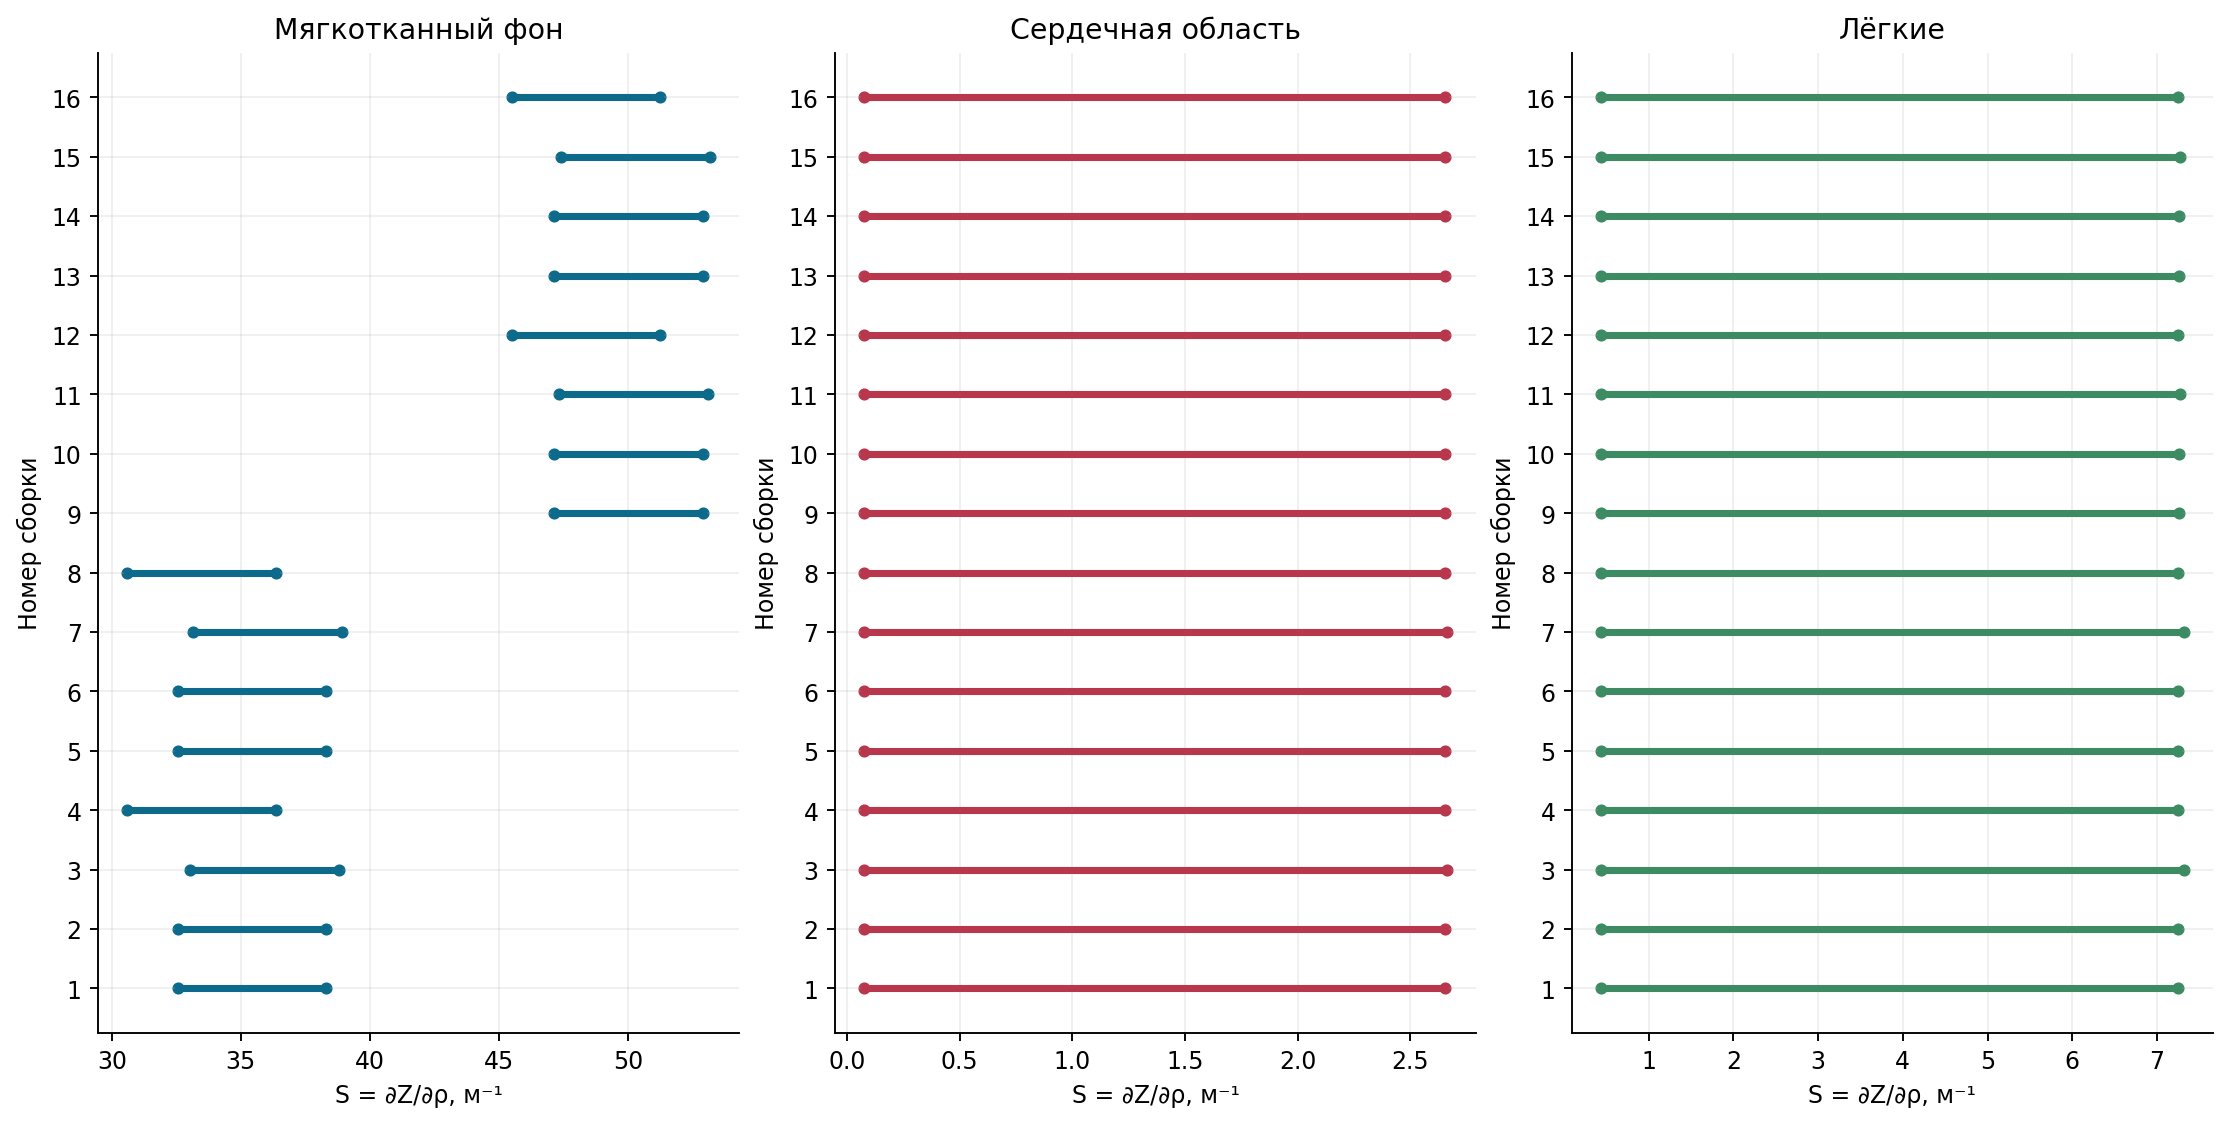

**Рисунок 5.** Знаковые диапазоны производных по всем 125 основным и 64 контрольным состояниям каждой сборки. Концы отрезков обозначают найденные выборочные экстремумы; непрерывные экстремумы по всему диапазону не предполагаются известными.

**Анализ рисунка 5.** Во всех рассчитанных состояниях производные положительны. Следовательно, увеличение ρ каждого компартмента сопровождалось увеличением передаточного импеданса. Изменения знака производной не обнаружено.

Диапазоны производных:

- **Мягкотканный фон:** 30,6–53,18 м⁻¹; отношение максимума к минимуму 1,7.
- **Сердечная область:** 0,07662–2,662 м⁻¹; отношение максимума к минимуму 34,7.
- **Лёгкие:** 0,4383–7,315 м⁻¹; отношение максимума к минимуму 16,7.

Сердечная и лёгочная производные меняются между фоновыми состояниями сильнее, чем мягкотканная. Поэтому одного расчёта при номинальных значениях ρ недостаточно для описания всего литературного диапазона.

Большая мягкотканная производная характеризует модельную чувствительность к равномерному изменению всей мягкотканной маски. Она не доказывает, что мягкие ткани создают основную часть реального пульсового сигнала: физиологические амплитуды изменений ρ на этом этапе не заданы.

In [6]:
report.derivative_ranges(r,5)
interpretation.derivative_analysis(r)

## 5. Точность интерполяции производных

Интерполированные производные сравниваются с производными, рассчитанными непосредственно в контрольных состояниях. Ошибка делится на установленный допуск: значение меньше единицы означает выполнение критерия. Для каждого состояния приводится наибольшее отношение среди 16 сборок.

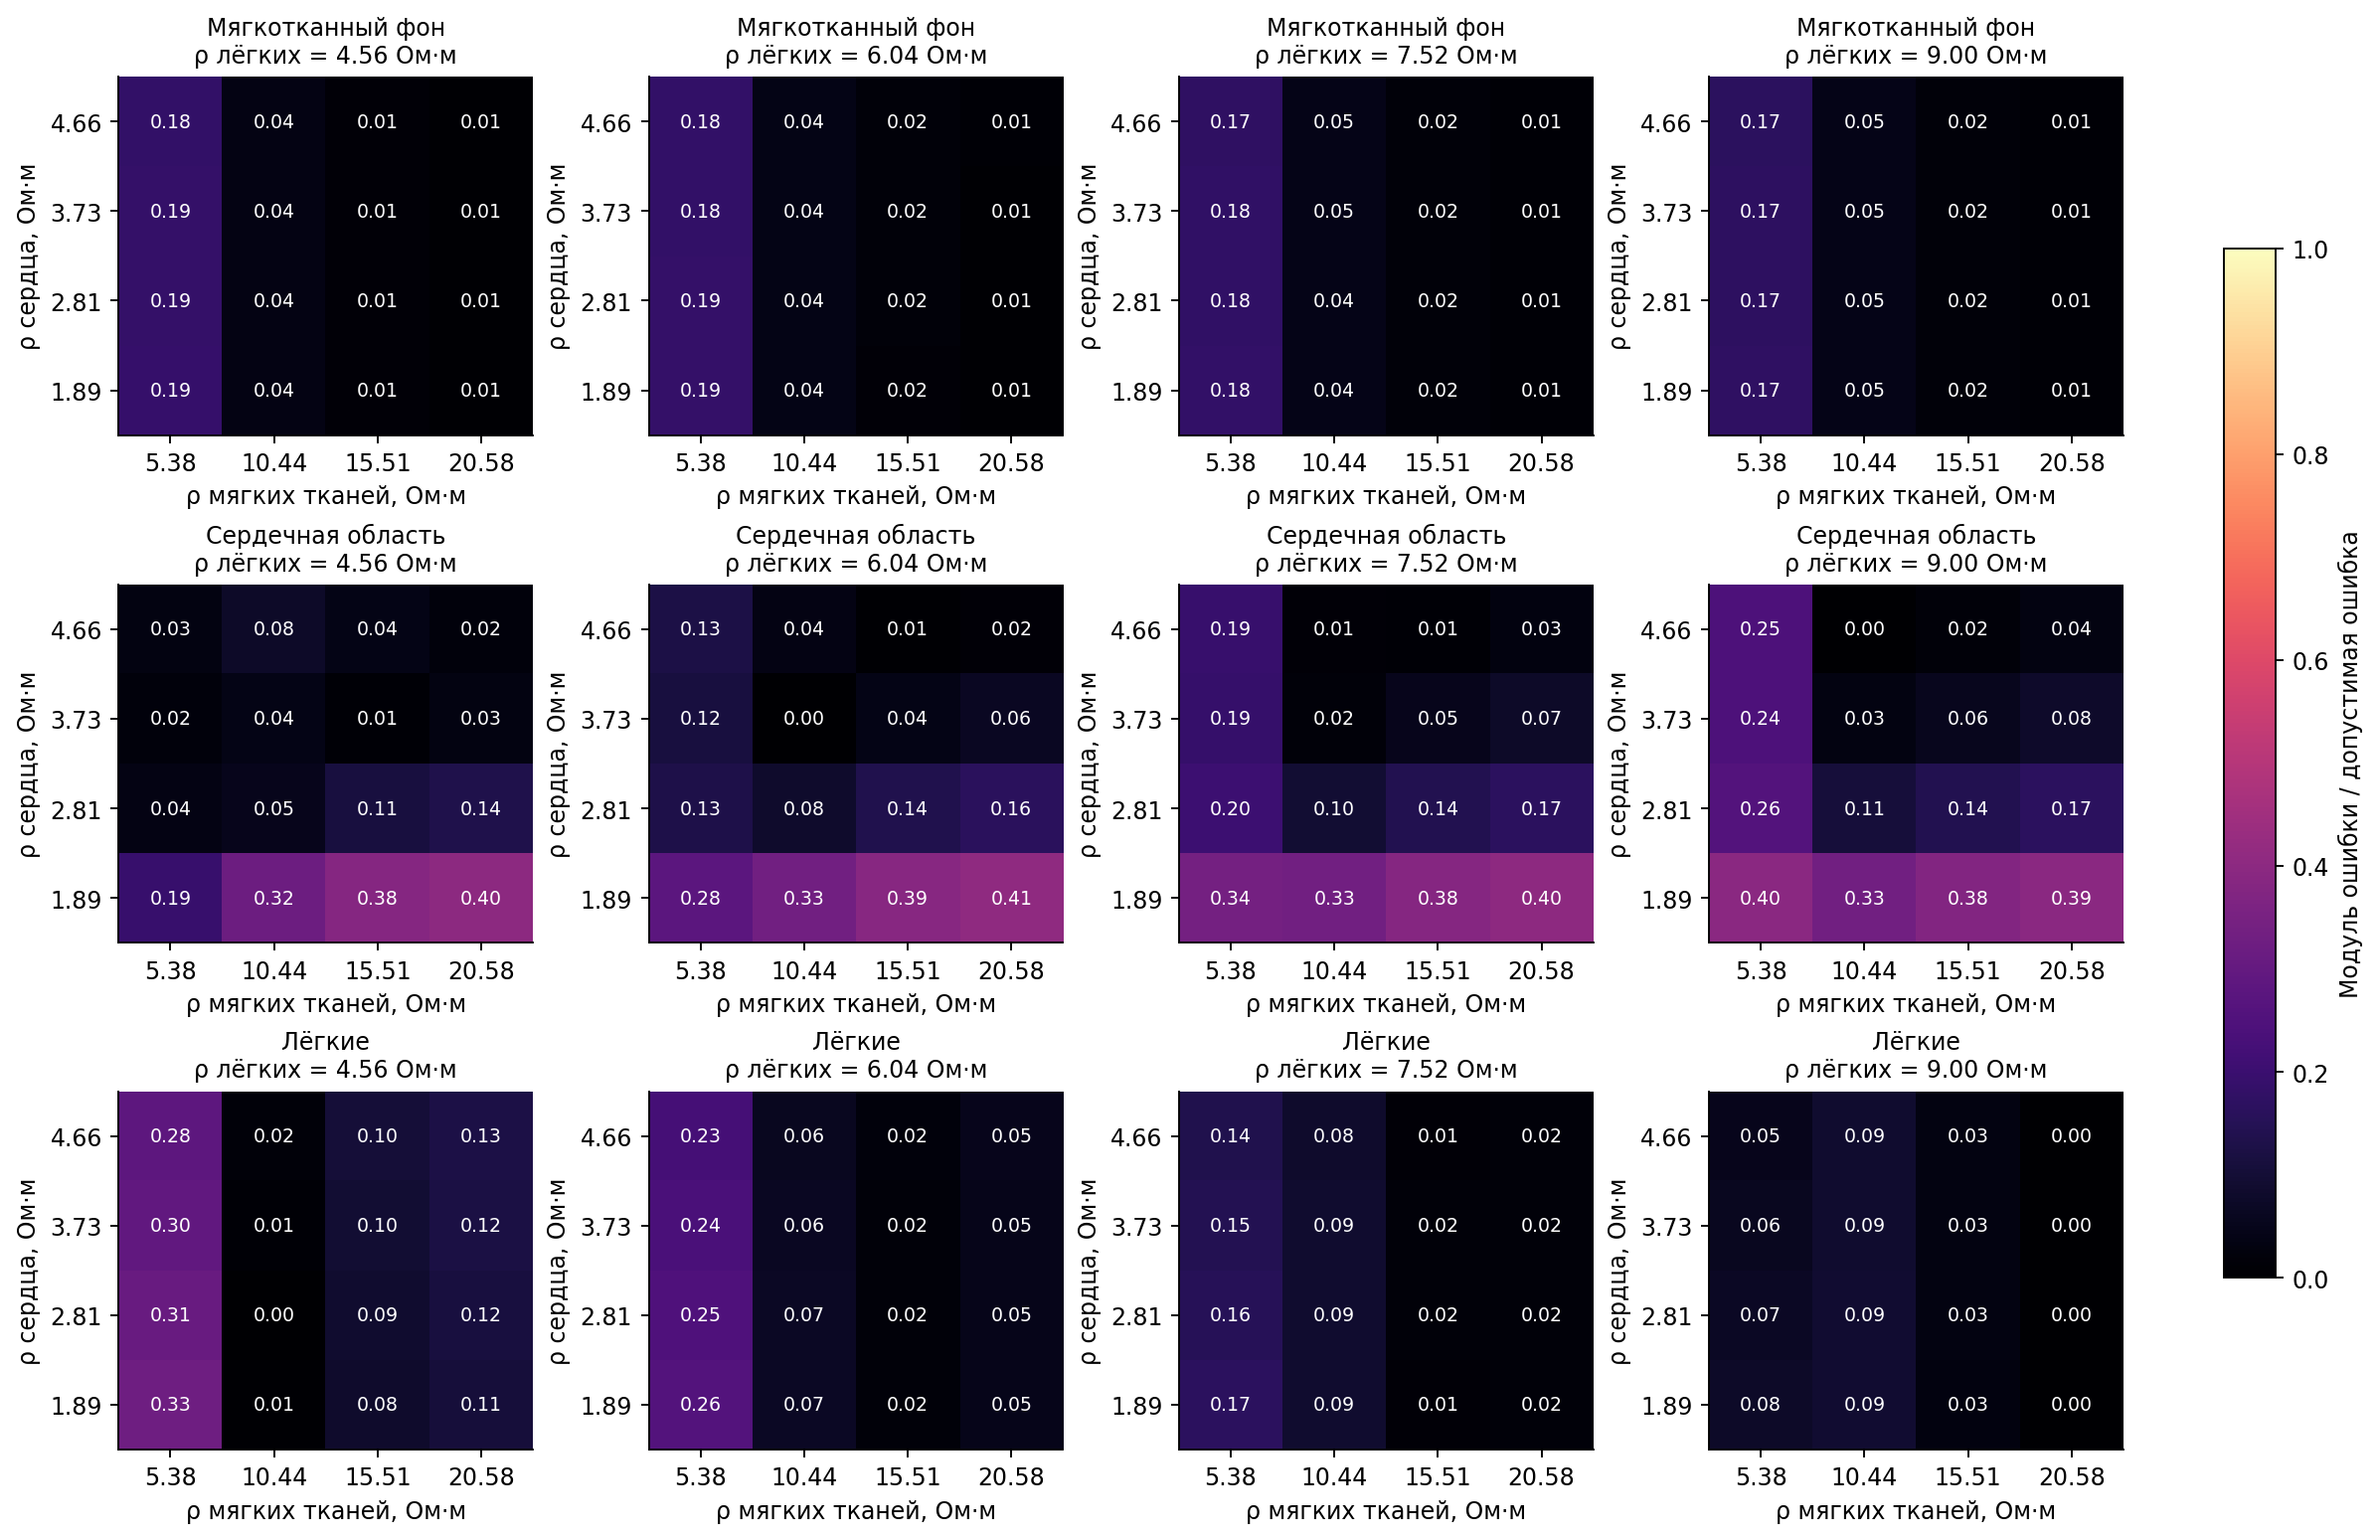

**Рисунок 6.** Отношение ошибки к допуску для производной, максимальное среди 16 сборок. Значение больше единицы означает невыполнение критерия. Каждый столбец соответствует одному промежуточному сопротивлению лёгких; внутри панели изменяются сопротивления мягких тканей и сердца.

Компартмент,Не прошли проверки S,"Макс. ошибка S, %","Макс. ошибка Q, п.п.",Не прошли парные проверки |S|,Не прошли парные проверки Q
Мягкотканный фон,0,1.0449,0.0600,0,0
Сердечная область,0,2.9453,0.0251,444,0
Лёгкие,0,2.1594,0.0610,432,0


Компартмент,Максимум ошибки / допуска,"Максимальная относительная ошибка S, %","Максимальная ошибка Q, п.п.",Непройденные проверки
Мягкотканный фон,"0,1882","1,0449","0,0600",0
Сердечная область,"0,4083","2,9453","0,0251",0
Лёгкие,"0,3271","2,1594","0,0610",0


**Анализ рисунка 6.** На рисунке показано отношение ошибки интерполяции к установленному допуску. Значение меньше единицы означает выполнение критерия.

Максимальное отношение равно 0,188 для мягких тканей, 0,408 для сердца и 0,327 для лёгких. Иными словами, наибольшая обнаруженная ошибка занимает соответственно 18,8, 40,8 и 32,7 % допуска. Все индивидуальные проверки S и Q прошли критерий.

Наибольшие ошибки получены в следующих состояниях: мягкотканный фон — сборка № 4, ρ = (5,376; 1,888; 4,558) Ом·м; сердечная область — сборка № 7, ρ = (20,575; 1,888; 6,039) Ом·м; лёгкие — сборка № 8, ρ = (5,376; 1,888; 4,558) Ом·м.

**Вывод.** Сетка 5 × 5 × 5 достаточно подробно воспроизводит S и Q отдельной сборки в 64 контрольных точках. Этот вывод относится к интерполяции по ρ. Он не оценивает погрешность анатомической модели, конечноэлементной сетки или эксперимента.

In [7]:
report.error_maps(r,"derivative",6)
report.error_table(r)
interpretation.individual_accuracy_analysis(r)

## 6. Точность межсборочных различий

Даже точная оценка каждой сборки не гарантирует точности их разности. Если различие между сборками мало, ошибка интерполяции может изменить их порядок. Поэтому ниже отдельно проверяется ошибка парной разности. Если прямое различие меньше заданной численной полосы, сборки считают неразличимыми, но ошибка их разности всё равно должна пройти допуск.

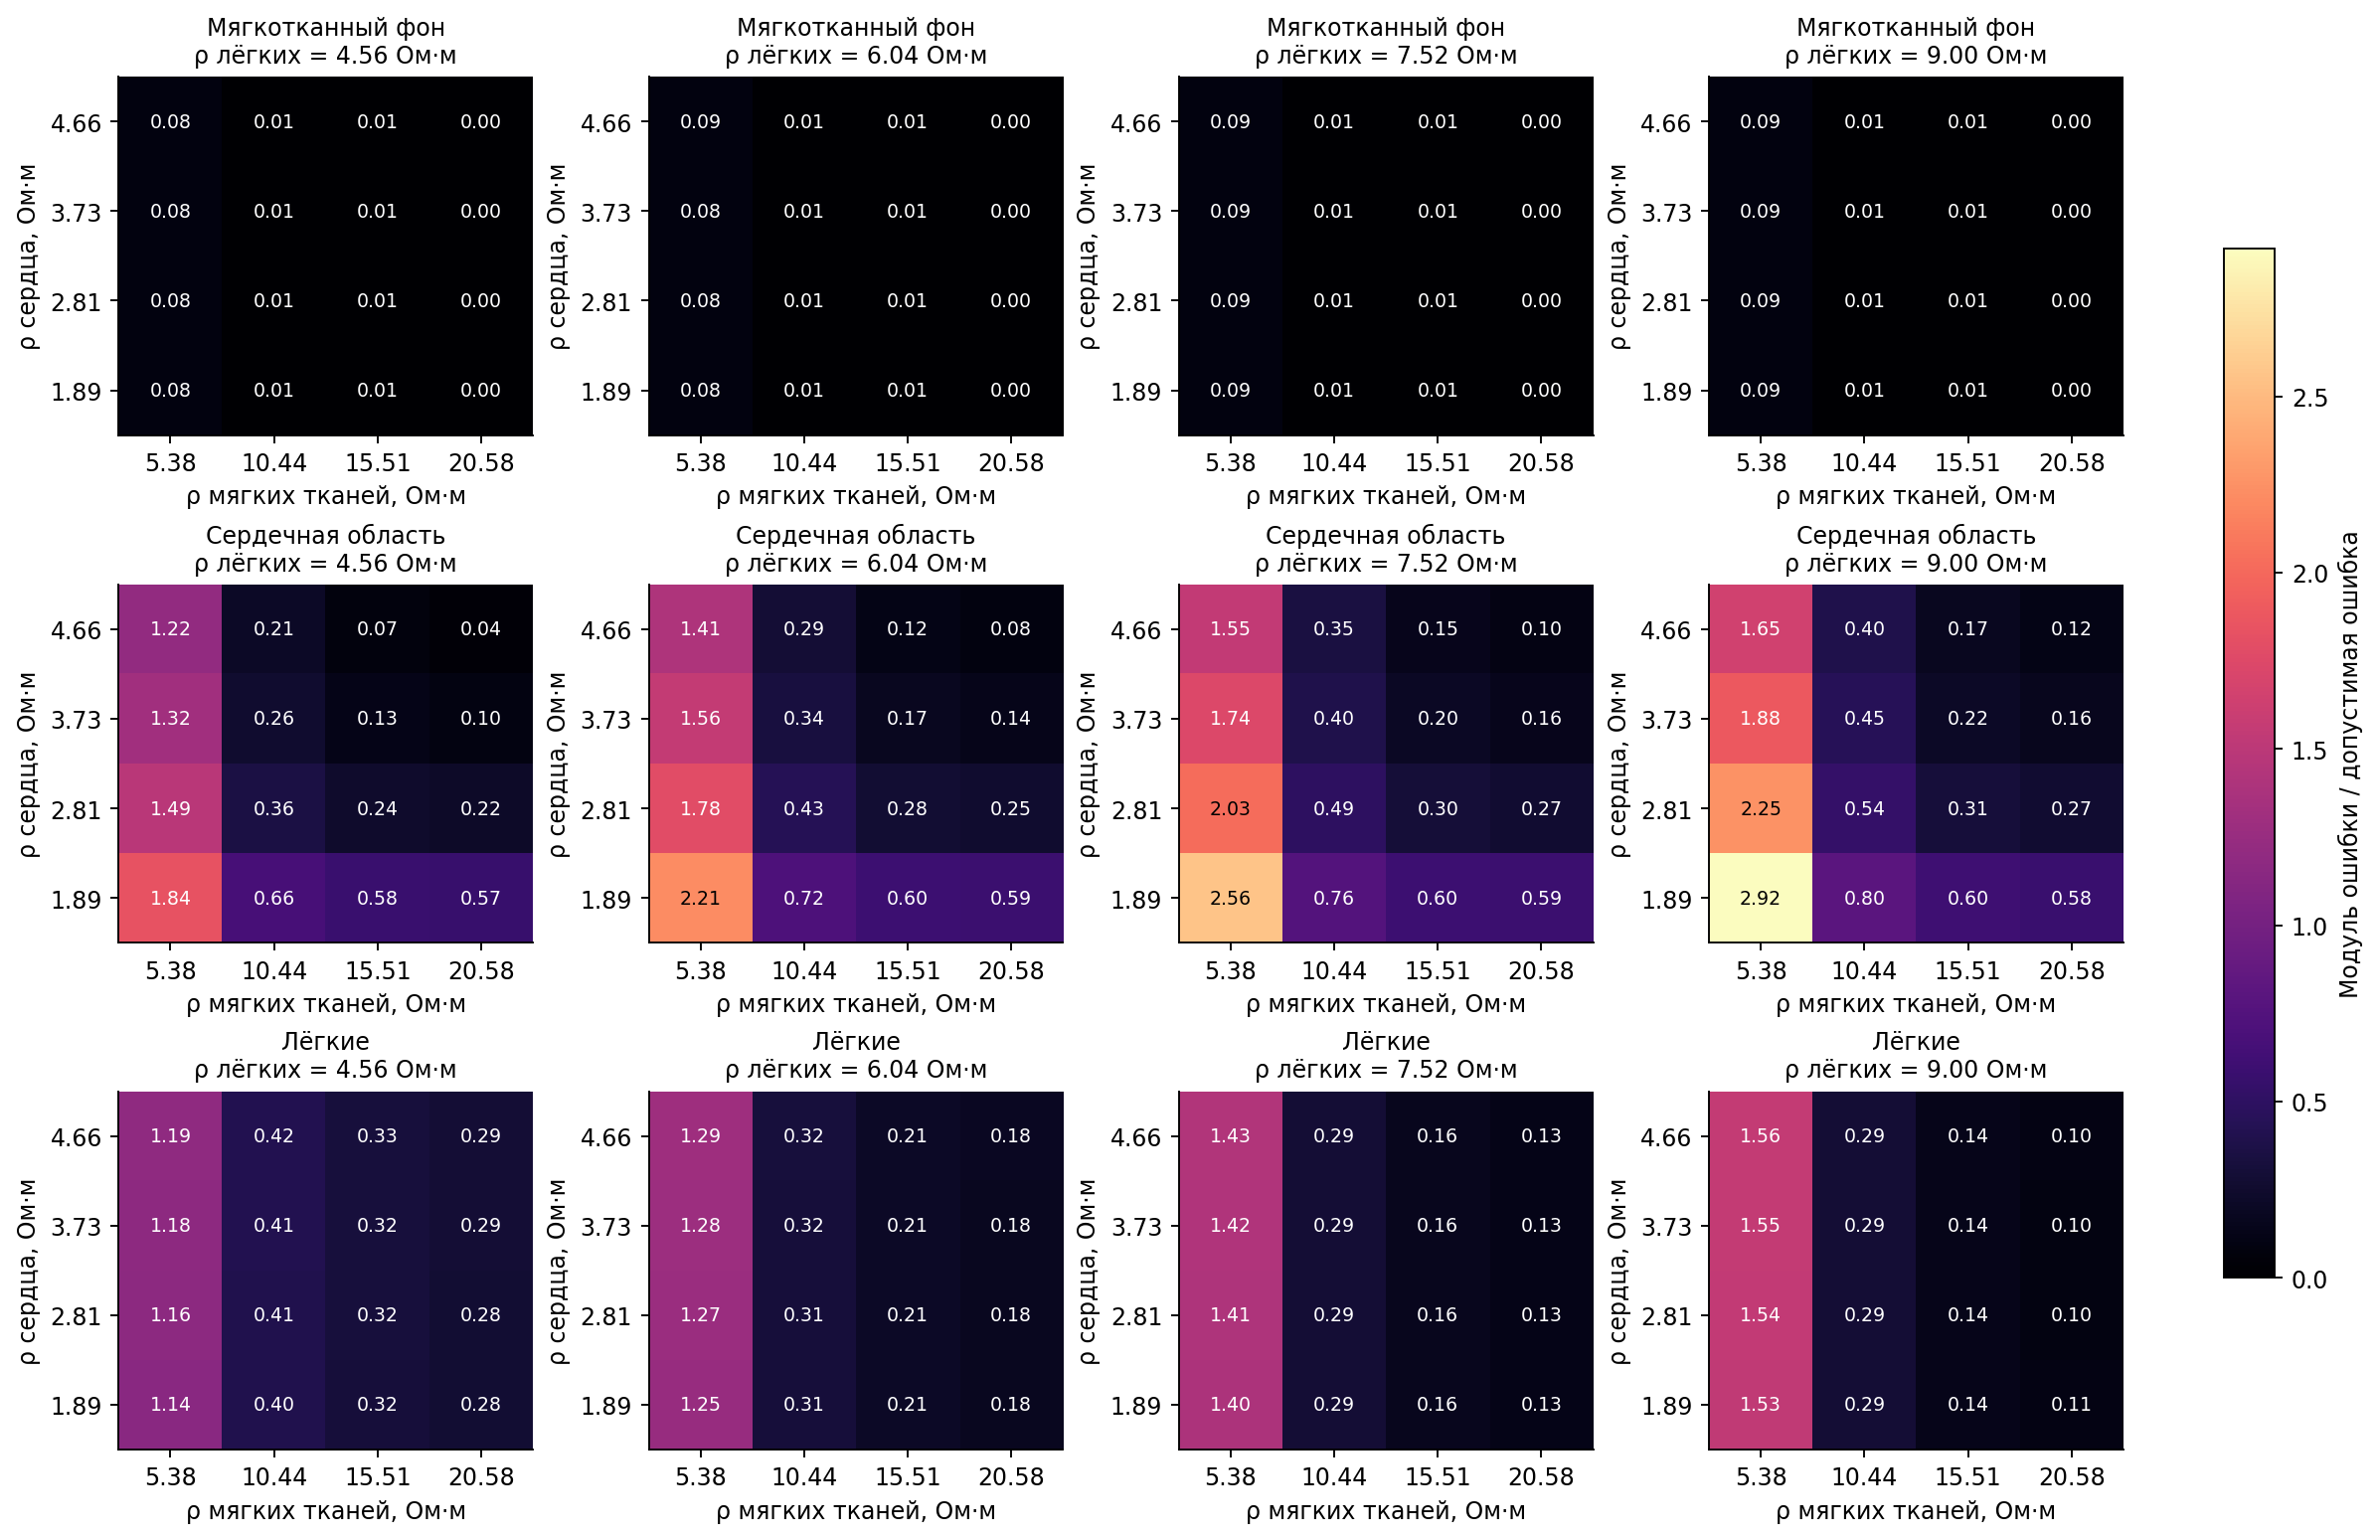

**Рисунок 7.** Отношение ошибки к допуску для парной разности модулей производных, максимальное среди 120 пар. Значение больше единицы означает невыполнение критерия. Каждый столбец соответствует одному промежуточному сопротивлению лёгких; внутри панели изменяются сопротивления мягких тканей и сердца.

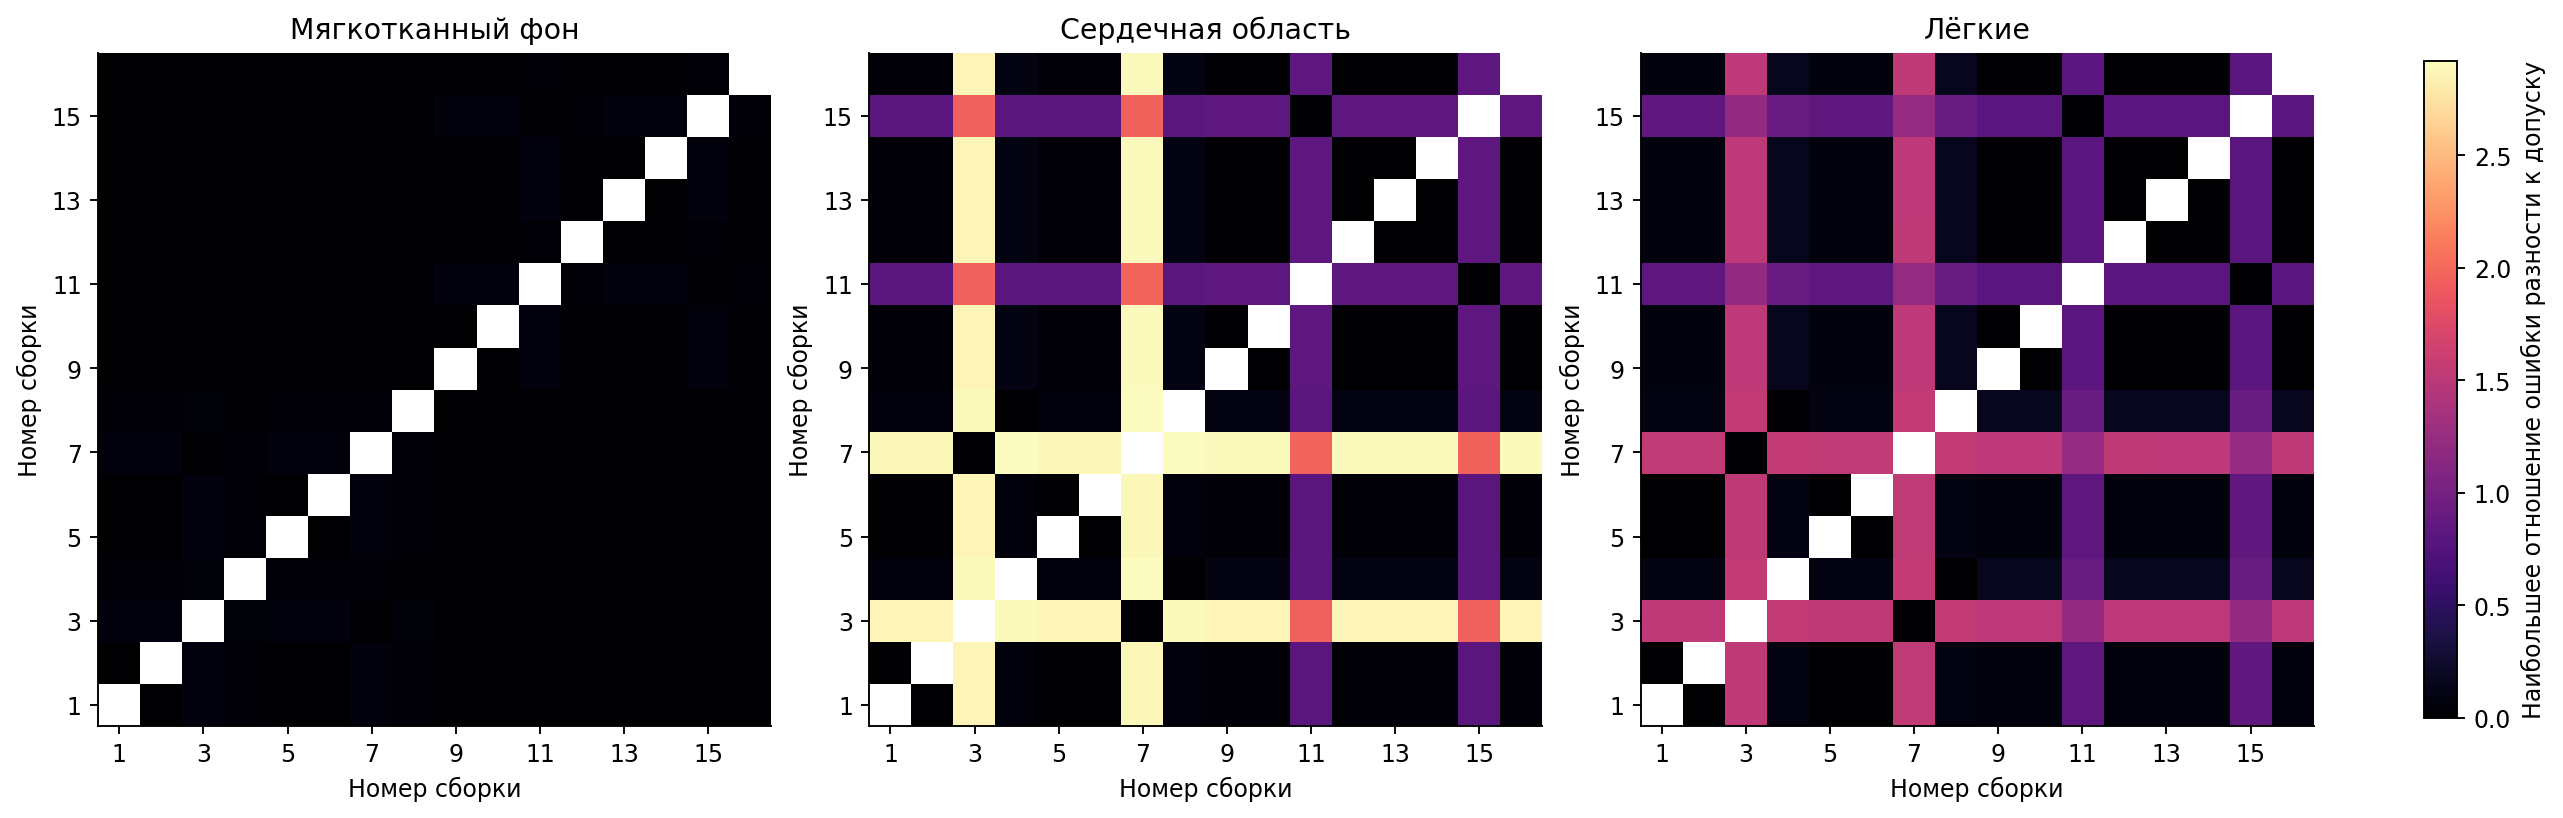

**Рисунок 8.** Контроль межсборочных различий: для каждой пары показано наибольшее отношение ошибки к допуску среди 64 контрольных состояний. Диагональ не содержит сравнения. Ошибки двух сборок проверяются совместно, поэтому их возможная компенсация сохранена.

Компартмент,Непройдено из 7680,Затронуто пар из 120,Затронуто состояний из 64,Максимум ошибки / допуска,Непройденные проверки Q
Мягкотканный фон,0,0,0,"0,090",0
Сердечная область,444,28,16,"2,920",0
Лёгкие,432,28,16,"1,559",0


**Анализ рисунков 7 и 8.** Эти рисунки проверяют не отдельные значения чувствительности, а разность между двумя сборками. Такая проверка необходима, поскольку малая ошибка каждой сборки может стать существенной по сравнению с ещё меньшей межсборочной разностью.

Для мягких тканей все парные сравнения прошли критерий. Для сердца допуск превышен в 444 из 7680 проверок, для лёгких — в 432 из 7680. Нарушения относятся к 28 из 120 пар и к 16 из 64 контрольных состояний. Каждая проблемная пара включает дисковую сборку № 3 или № 7; сравнение № 3 с № 7 проходит критерий.

Наибольшие ошибки: сердечная область — 2,920 у пары № 7–8 при ρ = (5,376; 1,888; 9,001) Ом·м; лёгкие — 1,559 у пары № 7–8 при ρ = (5,376; 4,656; 9,001) Ом·м. Они превышают допуск в 2,92 раза для сердца и в 1,56 раза для лёгких. Все парные проверки Q прошли.

Изменение знака очень малой разности отмечено 153 раз для сердца и 36 раз для лёгких. Во всех этих случаях сама разность находится внутри полосы численной неразличимости, поэтому устойчивого обращения предпочтения не установлено.

**Вывод.** Текущая сетка достаточна для оценки отдельной сборки, но пока недостаточна для окончательного ранжирования близких сборок по сердечному и лёгочному B.

In [8]:
report.error_maps(r,"pairs",7)
report.pair_matrix(r,8)
interpretation.pair_accuracy_analysis(r)

## 7. Устойчивость минимальных показателей

Минимальные B и Q характеризуют наименее благоприятное из рассчитанных состояний. При добавлении новых состояний минимум может сохраниться или уменьшиться. Поэтому значения сравниваются на сетках 3³ и 5³, а затем после добавления 64 контрольных точек.

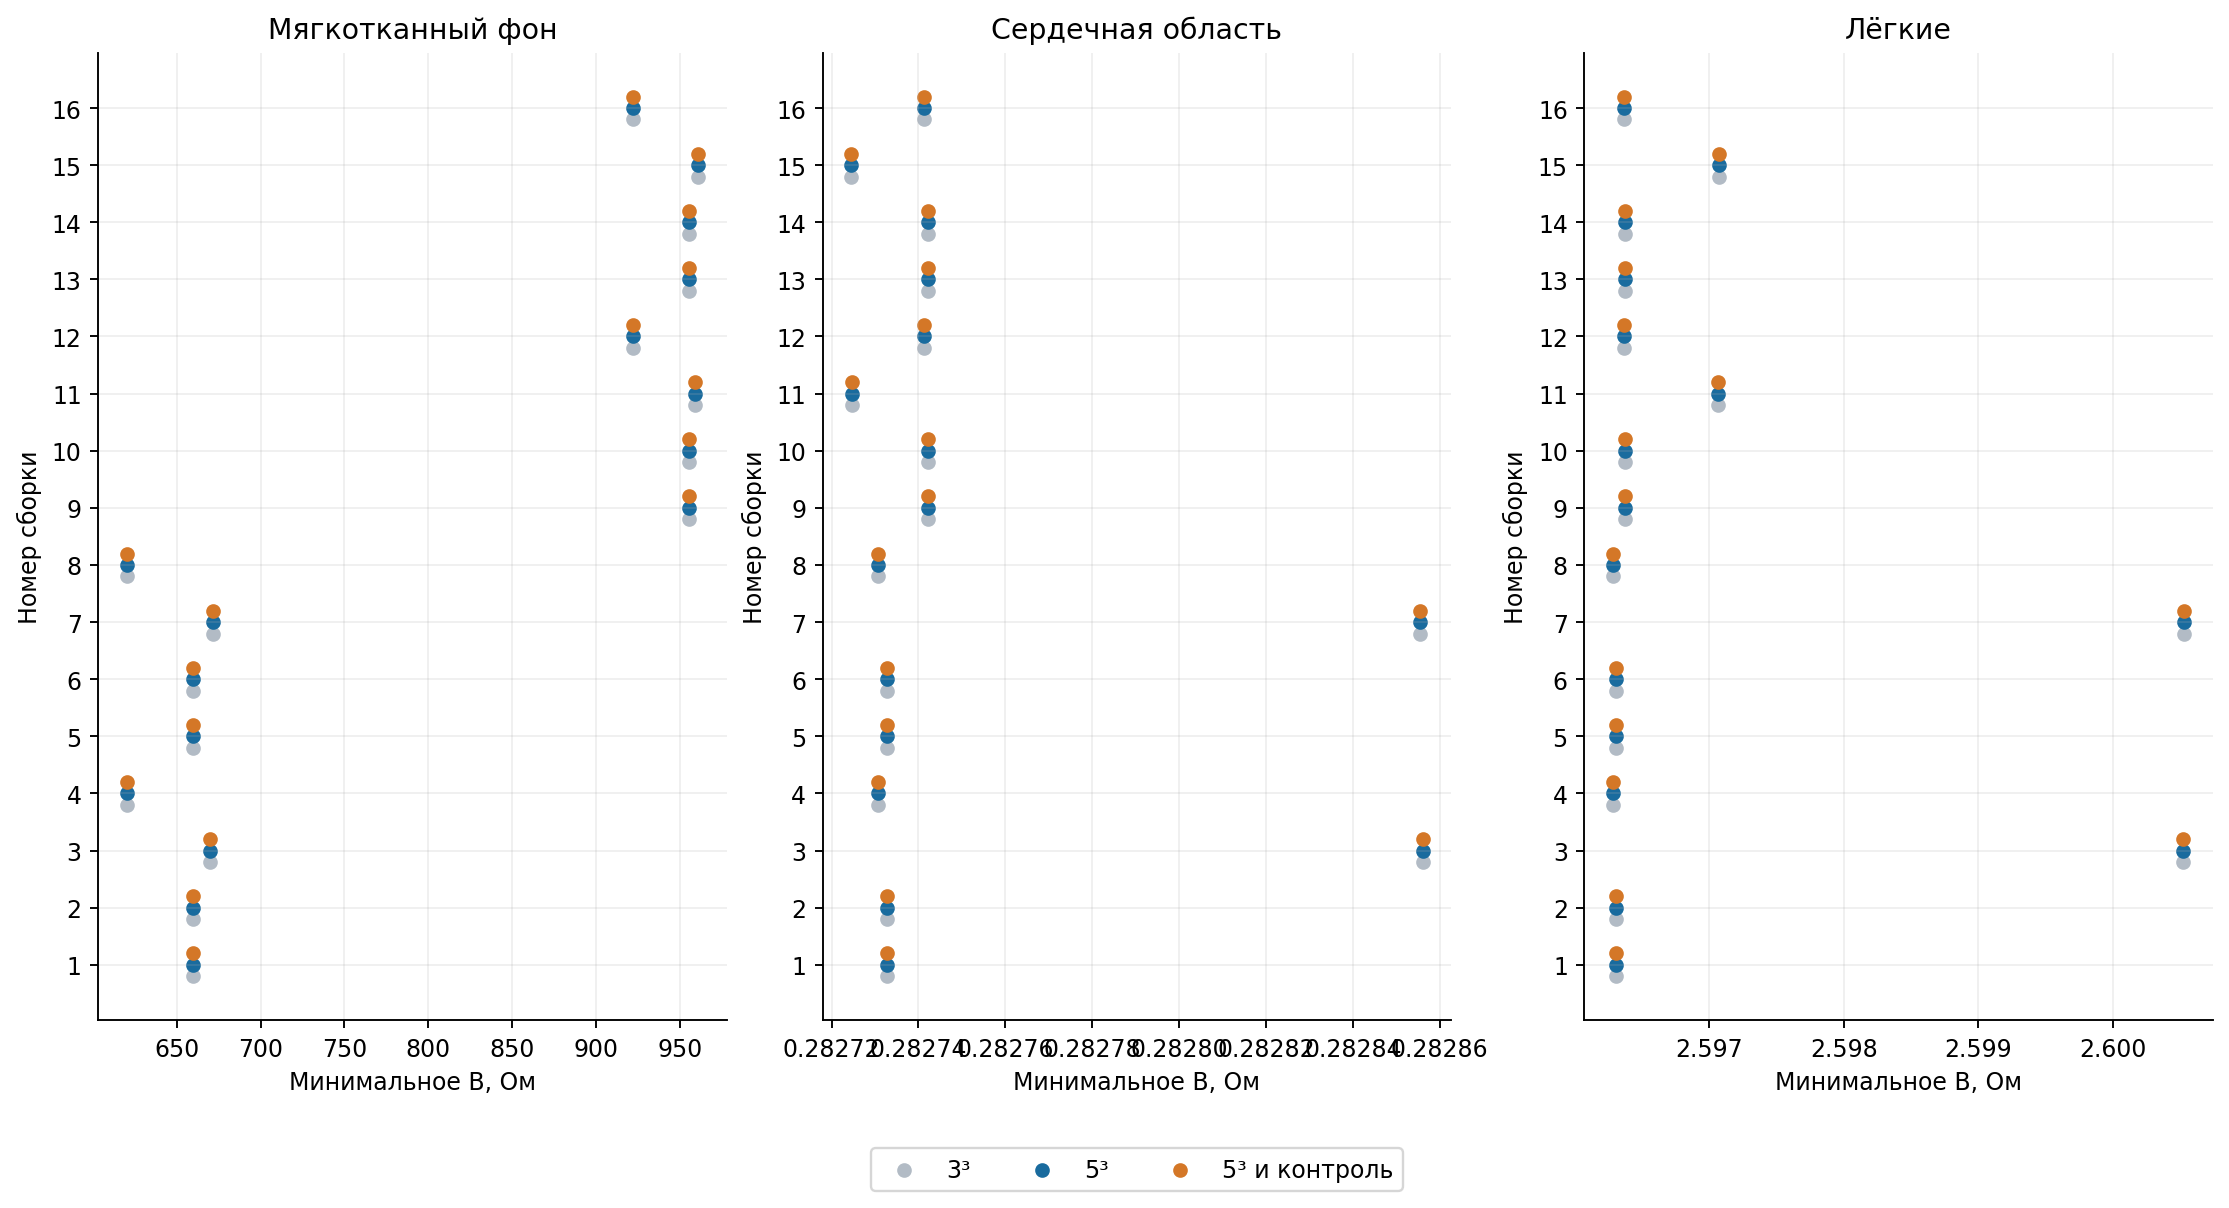

**Рисунок 9.** Изменение минимальных значений целевого масштабированного влияния B при увеличении числа состояний. Минимум определяется отдельно для каждой сборки и компартмента. Сравниваются вложенные 27 узлов, полный набор 125 узлов и его объединение с 64 независимыми контрольными состояниями.

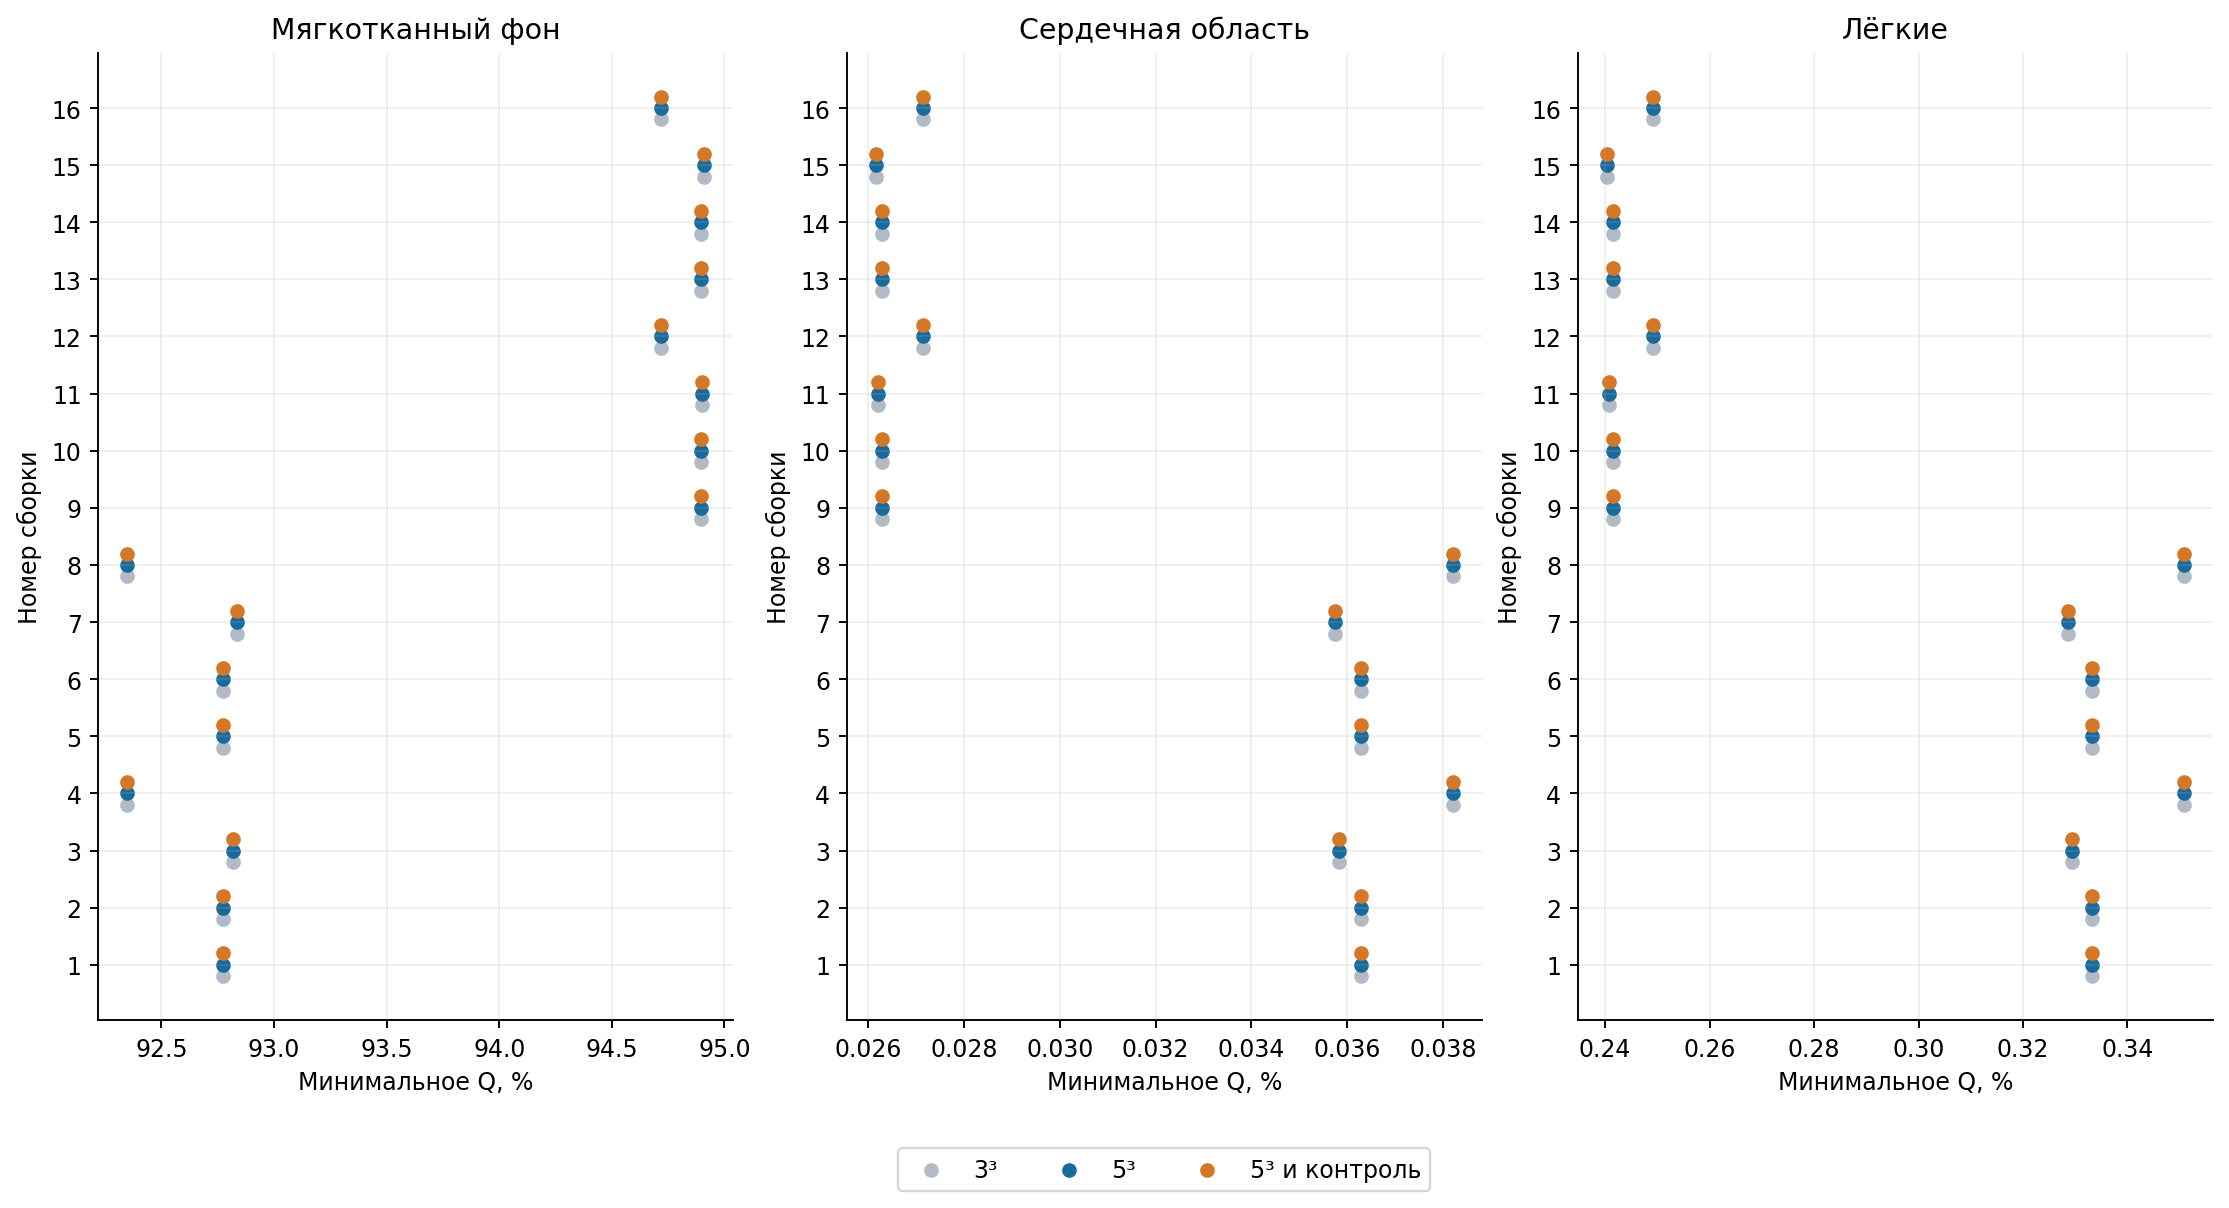

**Рисунок 10.** Изменение минимальных значений избирательности Q при увеличении числа состояний. Минимум определяется отдельно для каждой сборки и компартмента. Сравниваются вложенные 27 узлов, полный набор 125 узлов и его объединение с 64 независимыми контрольными состояниями.

Компартмент,"Диапазон минимального B, Ом","Диапазон минимального Q, %","Относительный разброс B, %"
Мягкотканный фон,"620,244–960,889","92,3474–94,9111","35,451044"
Сердечная область,"0,282725–0,282856","0,0262–0,0382","0,046501"
Лёгкие,"2,59628–2,60053","0,2403–0,3508","0,163340"


**Анализ рисунков 9 и 10.** Минимальные B и Q каждой сборки сравнивались на трёх последовательных наборах состояний: сетке 3³, сетке 5³ и сетке 5³ вместе с 64 контрольными точками.

Во всех случаях минимальные значения совпали в сохранённой численной точности. Дополнительные внутренние состояния не дали меньших B или Q. Следовательно, найденные минимумы устойчивы к выполненному сгущению сетки по ρ.

Этот результат относится только к положению и величине минимумов. Он не подтверждает одинаковую точность всей поверхности чувствительности. Рисунки 7 и 8 показывают, что разности между близкими сборками всё ещё требуют уточнения.

In [9]:
report.minima(r,"min_B",9)
report.minima(r,"min_Q",10)
interpretation.minima_analysis(r)

### Предпочтительные множества сборок

Для каждого компартмента и показателя выбираются сборки, находящиеся в заданной численной полосе около максимума. Список кандидатов сравнивается на трёх наборах состояний. Он считается устойчивым только при полном совпадении состава. Результат относится к выбранной модели и литературным диапазонам ρ.

In [10]:
report.selection(r)
interpretation.selection_analysis(r)

Цель,Критерий,3³,5³,5³ и контроль,Множество устойчиво
Мягкотканный фон,Минимальное B,15,15,15,Да
Мягкотканный фон,Минимальное Q,"11, 15","11, 15","11, 15",Да
Сердечная область,Минимальное B,"3, 7","3, 7","3, 7",Да
Сердечная область,Минимальное Q,"1, 2, 3, 4, 5, 6, 7, 8","1, 2, 3, 4, 5, 6, 7, 8","1, 2, 3, 4, 5, 6, 7, 8",Да
Лёгкие,Минимальное B,"3, 7","3, 7","3, 7",Да
Лёгкие,Минимальное Q,"4, 8","4, 8","4, 8",Да


Числа обозначают сборки из таблицы геометрии. Множества формируются с учётом заранее заданной численной полосы. Несколько номеров в ячейке означают отсутствие единственного предпочтительного кандидата по данному критерию на соответствующем этапе.

**Анализ предпочтительных множеств.** Сборки, попавшие в численную полосу около максимума, следует рассматривать как равноправных кандидатов.

- Для мягких тканей наибольшее из минимальных значений B получено для дисков диаметром 5 мм при d = 40 мм и l = 80 мм (№ 15). По Q выделены такие же диски при l = 100 и 80 мм (№ 11 и № 15).
- Для сердца по B выделены диски диаметром 5 мм при d = 20 мм и l = 100 или 80 мм (№ 3 и № 7). По Q единственного лидера нет: в предпочтительное множество входят все сборки с d = 20 мм (№ 1–8).
- Для лёгких по B выделены сборки № 3 и № 7. По Q выделены манжеты шириной 15 мм при d = 20 мм и l = 100 или 80 мм (№ 4 и № 8).

Разброс минимального B между 16 сборками составляет 35,45 % для мягких тканей, 0,047 % для сердца и 0,163 % для лёгких. Следовательно, в данной модели сборка заметно влияет на мягкотканный отклик, тогда как сердечные и лёгочные различия B малы.

Минимальное Q составляет 92,35–94,91 % для мягких тканей, 0,026–0,038 % для сердца и 0,240–0,351 % для лёгких. Доминирование мягкотканного показателя связано с размером объединённой мягкотканной маски и с шириной выбранного диапазона ρ. Эти значения не являются долями реального пульсового или дыхательного сигнала.

## 8. Конечные изменения импеданса

Производная S описывает локальный наклон зависимости, а конечное изменение — разность непосредственно рассчитанных Z на нижней и верхней границах диапазона ρ. Эти величины могут различаться, если зависимость нелинейна.

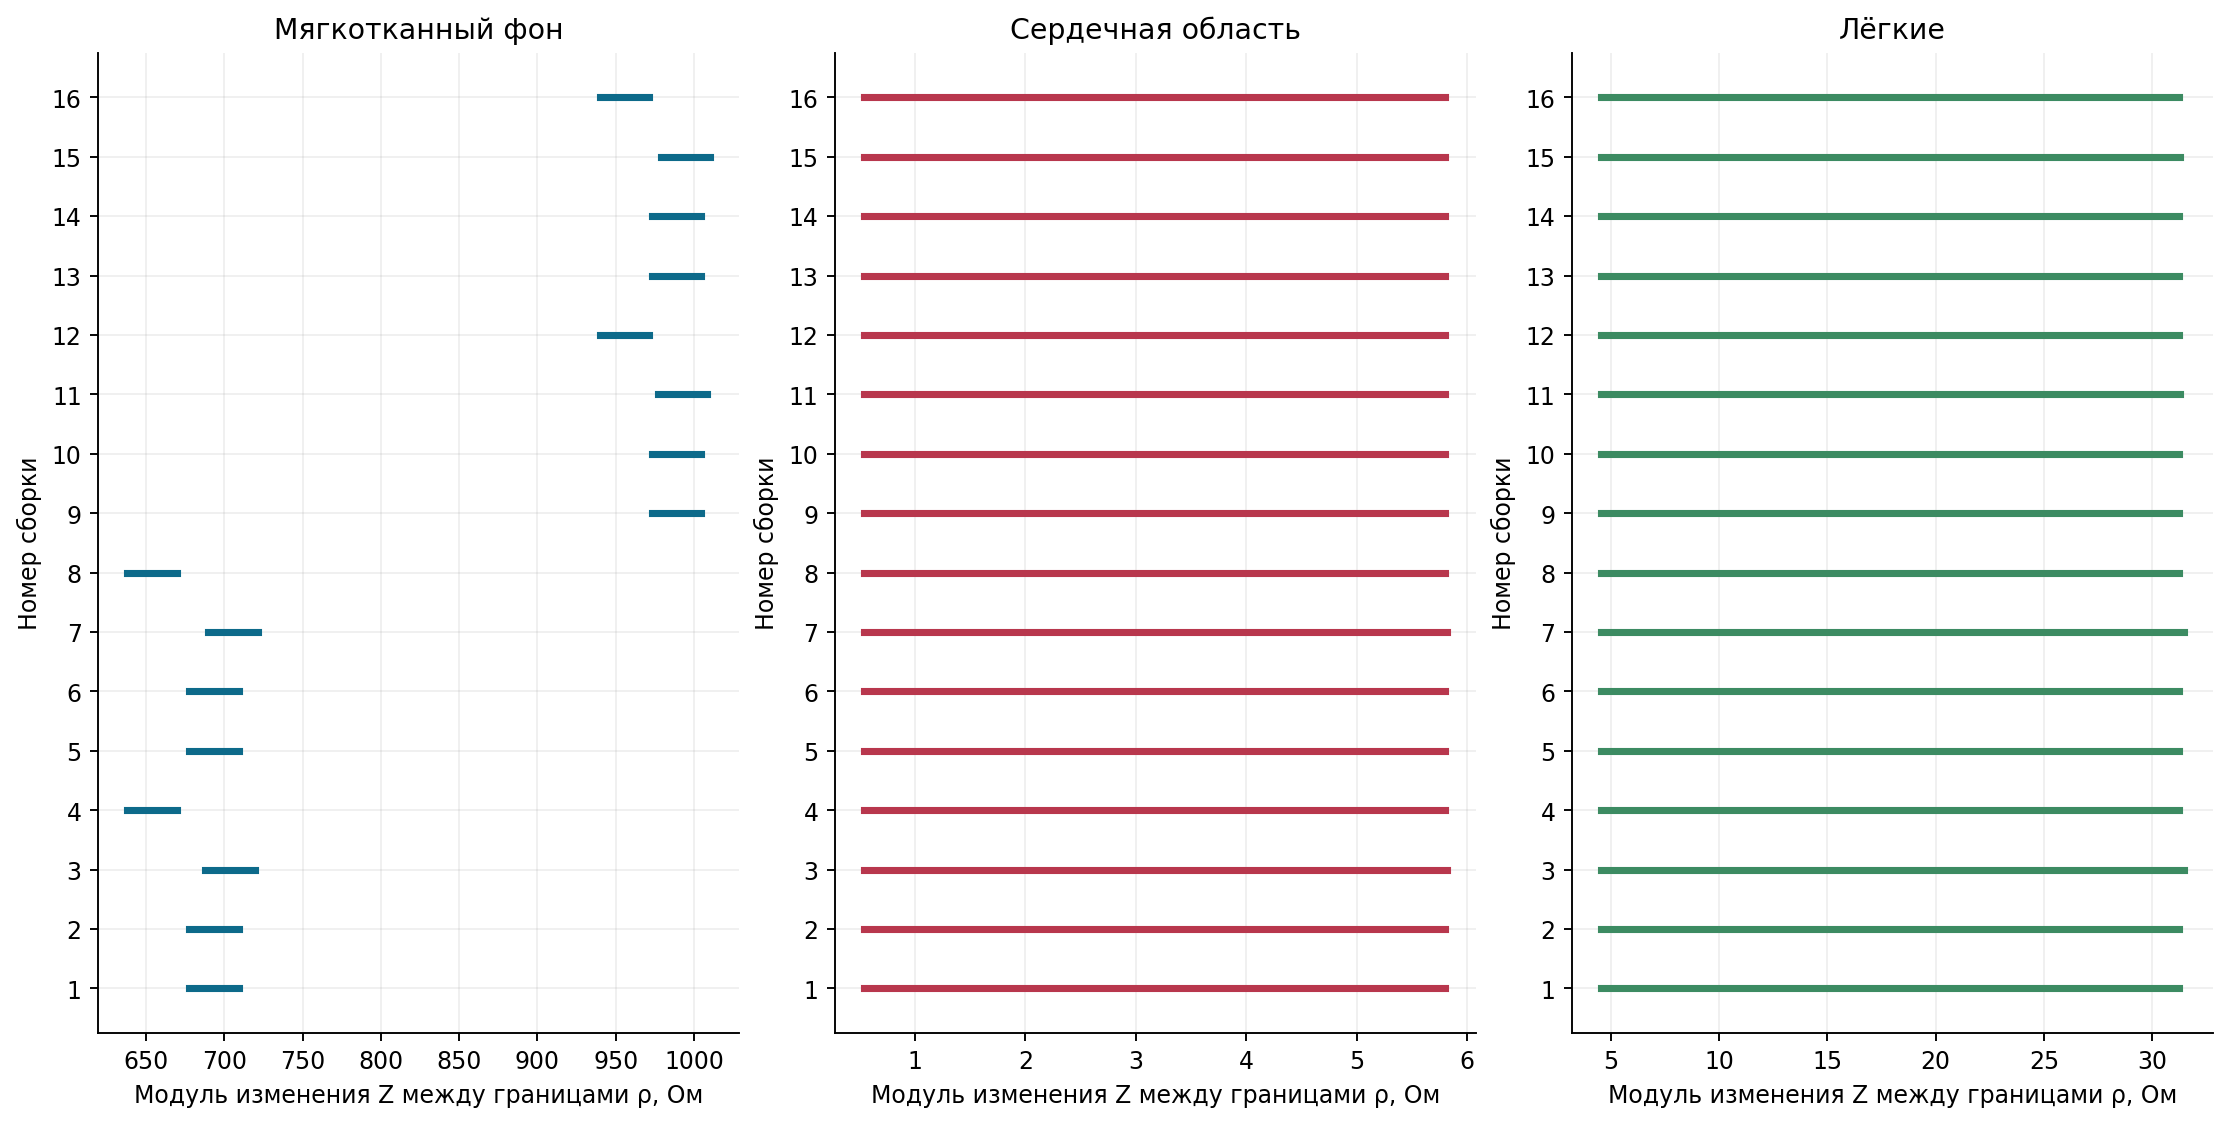

**Рисунок 11.** Конечные изменения импеданса при переходе между границами сопротивления одного компартмента. Для каждого целевого параметра перебраны 25 комбинаций двух остальных сопротивлений. Эти широкие модельные изменения не интерпретируются как амплитуды пульса или дыхания.

**Анализ рисунка 11.** Для каждой сборки изменялось сопротивление одного компартмента от нижней до верхней литературной границы. Сопротивления двух остальных компартментов принимали 25 разных сочетаний. Во всех 1200 проверенных сочетаниях Z изменялся монотонно.

Полученные диапазоны конечного изменения Z:

- **Мягкотканный фон:** 637,942–1010,228 Ом.
- **Сердечная область:** 0,541–5,815 Ом.
- **Лёгкие:** 4,548–31,451 Ом.

Для сердца и лёгких величина конечного изменения заметно зависит от сопротивлений остальных тканей. Поэтому чувствительность нельзя описывать одним постоянным коэффициентом без указания фонового состояния.

Переход между литературными границами значительно шире ожидаемых изменений за один сердечный или дыхательный цикл. Значения на рисунке характеризуют диапазон математической модели и не являются прогнозом амплитуды физиологического сигнала.

In [11]:
report.excursions(r,11)
interpretation.excursion_analysis(r)

## 9. Ограничения и границы применимости

Ограничения перечислены по источникам неопределённости, чтобы численная проверка параметрической сетки не подменяла пространственную, анатомическую и экспериментальную валидацию.

In [12]:
interpretation.limitations(r)

Область,Граница применимости
Параметрическое покрытие,Проверена интерполяция по ρ в 64 центрах ячеек. Общий критерий не пройден для части сердечных и лёгочных межсборочных разностей.
Пространственная дискретизация,Сходимость по размеру конечных элементов в этой серии не проверялась; использована одна фиксированная FEM-сетка.
Анатомия,Исследован один вариант КТ-геометрии Nix. Ошибки сегментации и перенос между людьми не оценивались.
Сердечный компартмент,Вся маска сердца рассматривается как эффективная смесь крови и миокарда; доля крови не измерена и отдельно не изменяется.
Электроды,"Положение, площадь и контактные свойства фиксированы. Ошибки наклейки, контактный импеданс и взаимное влияние каналов не варьировались."
Физиологическая интерпретация,"Литературные интервалы ρ задают общий масштаб, но не распределение параметров и не амплитуды пульса или дыхания."
Идентифицируемость,Один передаточный импеданс не обеспечивает раздельное восстановление трёх неизвестных ρ; матрица многоканальной обратной задачи не исследовалась.
Валидация,"Невязка и взаимность подтверждают внутреннюю согласованность вычислений, но отсутствует независимое экспериментальное подтверждение рассчитанных чувствительностей."


Численные лидеры следует трактовать как кандидатов для следующего этапа, а не как оптимальные клинические сборки. Особенно осторожно следует относиться к малым различиям сердечного и лёгочного B: их практическую значимость нельзя оценить до количественной проверки влияния положения электродов, контакта и межиндивидуальной анатомии.

In [13]:
interpretation.conclusion(r)

## 10. Заключение

1. **Расчётная сетка достаточна для оценки отдельной сборки.** Все 3072 проверки S и Q в промежуточных состояниях прошли установленный допуск.

2. **Для окончательного ранжирования близких сборок требуется уточнение.** Ошибка разности B превышает допуск в части сравнений сердца и лёгких, особенно для пар с дисковыми сборками № 3 или № 7.

3. **Для мягких тканей рекомендуется сборка № 15:** четыре диска диаметром 5 мм при d = 40 мм и l = 80 мм. Она имеет наибольшее минимальное B и входит в предпочтительное множество по Q.

4. **Для сердечной области рабочими кандидатами являются сборки № 3 и № 7:** четыре диска диаметром 5 мм при d = 20 мм и l = 100 или 80 мм. Они имеют наибольшее минимальное B, но превосходство мало: разброс B между всеми сборками составляет 0,047 %. По Q единственный лидер не установлен.

5. **Для лёгких рекомендация зависит от критерия.** По абсолютному влиянию B выделены дисковые сборки № 3 и № 7. По избирательности Q выделены манжеты шириной 15 мм № 4 и № 8 при d = 20 мм. Разброс лёгочного B между всеми сборками составляет только 0,163 %, поэтому при приоритете избирательности следует сохранять № 4 и № 8.

6. **Положение d влияет преимущественно на избирательность.** Переход от d = 40 к 20 мм увеличил значения Q сердца и лёгких примерно на 37,9 %, но почти не изменил их B. Одновременно мягкотканное B уменьшилось примерно на 31 %.

7. **Изменение l от 100 до 80 мм не дало устойчивого выигрыша.** В исследованном диапазоне это расстояние можно выбирать по удобству установки, сохраняя оба варианта для контрольного сравнения.

8. **Увеличение ширины манжеты с 5 до 15 мм повысило Q, но не B сердца и лёгких.** Значения B для сердца и лёгких изменились менее чем на 0,002 %, а соответствующие значения Q выросли в среднем на 4,255 % относительно исходного значения. Причина состоит в уменьшении мягкотканного B примерно на 4,75 %. Значение 4,255 % является относительным изменением, а не увеличением на 4,255 процентного пункта.

9. **Рекомендации относятся к одной математической модели.** Пока не проверены ошибки положения и контакта электродов, сходимость конечноэлементного решения по размеру сетки, межиндивидуальные различия анатомии и соответствие измеренным сигналам.

Рекомендуемый набор для следующего этапа: № 15 для мягких тканей; № 3 и № 7 для сердца; № 3 и № 7 для лёгочного B; № 4 и № 8 для лёгочного Q. Следующий расчёт должен уточнить межсборочные различия внутри этого набора и проверить устойчивость рекомендаций к ошибкам установки электродов.